In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1192_endo_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1165_endo.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1184_endo_watershed_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1198_endo_watershed_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1152_endo.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1177_endo_watershed_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1149_endo_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1164_endo_watershed_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1187_endo_watershed_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1216_endo.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/

In [2]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Torch: 2.10.0+cu128
CUDA available: True
Device: cuda


In [3]:

# %% CELL 1 — Environment setup
import os, glob, time, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
 
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "/kaggle/input/datasets/newslab/cholecseg8k"
OUT_DIR = "/kaggle/working/day1_2_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

Torch: 2.10.0+cu128
CUDA available: True


Found 8080 raw frame images (masks excluded)
Resolution stats (H, W) — mean: [480. 854.] min: [480 854] max: [480 854]
Found 101 video folders
Sampled 1515 frames across 101 videos


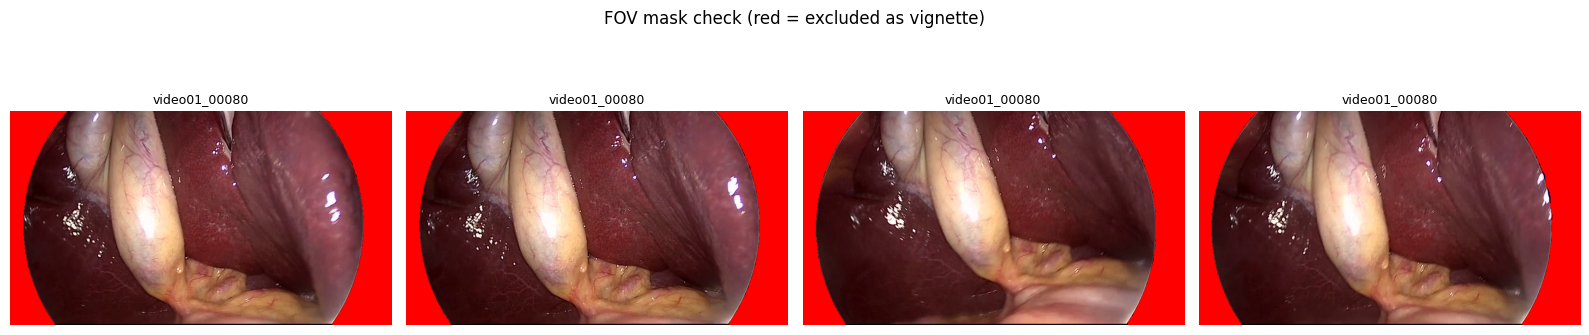

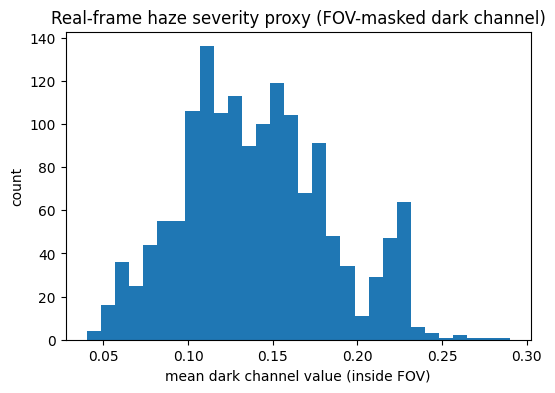

Severity bucket counts (0=low,1=med,2=high): {0: 500, 1: 500, 2: 515}


In [4]:
# %% CELL 3 — Dataset EDA (video-balanced sampling + FOV-masked severity)
import random
from collections import defaultdict

# Only keep raw endoscopic frames, exclude segmentation/annotation masks
image_paths = sorted(
    p for p in (glob.glob(os.path.join(DATA_DIR, "**", "*.png"), recursive=True) +
                glob.glob(os.path.join(DATA_DIR, "**", "*.jpg"), recursive=True))
    if "mask" not in os.path.basename(p).lower()
    and "watershed" not in os.path.basename(p).lower()
    and "color" not in os.path.basename(p).lower()
)
print(f"Found {len(image_paths)} raw frame images (masks excluded)")

if len(image_paths) == 0:
    print("No images found yet — attach a dataset in Kaggle's 'Add Data' panel "
          "and update DATA_DIR before continuing.")
else:
    # --- Resolution check across a random sample (not just the first N) ---
    res_sample = random.sample(image_paths, min(200, len(image_paths)))
    sizes = []
    for p in res_sample:
        im = cv2.imread(p)
        if im is not None:
            sizes.append(im.shape[:2])
    sizes = np.array(sizes)
    print("Resolution stats (H, W) — mean:", sizes.mean(axis=0),
          "min:", sizes.min(axis=0), "max:", sizes.max(axis=0))

    # --- Group frames by parent video folder to avoid sequential-slice bias ---
    by_video = defaultdict(list)
    for p in image_paths:
        video_id = os.path.basename(os.path.dirname(p))
        by_video[video_id].append(p)
    print(f"Found {len(by_video)} video folders")

    random.seed(42)
    N_PER_VIDEO = 15
    sampled_paths = []
    for vid, paths in by_video.items():
        sampled_paths.extend(random.sample(paths, min(N_PER_VIDEO, len(paths))))
    print(f"Sampled {len(sampled_paths)} frames across {len(by_video)} videos")

    # --- FOV mask: exclude black vignette border from all stats ---
    def get_fov_mask(img_rgb, thresh=0.03):
        """Boolean mask of the circular endoscopic FOV, excluding black vignette."""
        gray = img_rgb.mean(axis=2)
        mask = gray > thresh
        mask_u8 = (mask * 255).astype(np.uint8)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_CLOSE, kernel)
        mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN, kernel)
        return mask_u8 > 0

    def dark_channel_fov(img_rgb, fov_mask, patch=15):
        """Dark-channel haze-severity proxy, scored only inside the FOV."""
        min_c = np.min(img_rgb, axis=2)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (patch, patch))
        dc = cv2.erode(min_c, kernel)
        if fov_mask.sum() == 0:
            return float(dc.mean())  # fallback if mask fails
        return float(dc[fov_mask].mean())

    # --- Sanity-check a few FOV masks visually before trusting the stats ---
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, p in zip(axes, sampled_paths[:4]):
        im = cv2.imread(p)
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        mask = get_fov_mask(im)
        overlay = im.copy()
        overlay[~mask] = [1, 0, 0]  # highlight excluded region in red
        ax.imshow(overlay)
        ax.set_title(os.path.basename(os.path.dirname(p)), fontsize=9)
        ax.axis("off")
    plt.suptitle("FOV mask check (red = excluded as vignette)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "fov_mask_check.png"), dpi=120)
    plt.show()

    # --- Compute masked severity across the balanced sample ---
    severities = []
    valid_paths = []
    for p in sampled_paths:
        im = cv2.imread(p)
        if im is None:
            continue
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        mask = get_fov_mask(im)
        sev = dark_channel_fov(im, mask)
        severities.append(sev)
        valid_paths.append(p)

    plt.figure(figsize=(6, 4))
    plt.hist(severities, bins=30)
    plt.title("Real-frame haze severity proxy (FOV-masked dark channel)")
    plt.xlabel("mean dark channel value (inside FOV)")
    plt.ylabel("count")
    plt.savefig(os.path.join(OUT_DIR, "haze_severity_hist_masked.png"), dpi=120)
    plt.show()

    # --- Bucket into low/med/high smoke severity for stratified evaluation later ---
    sev_arr = np.array(severities)
    thresholds = np.quantile(sev_arr, [0.33, 0.66])
    buckets = np.digitize(sev_arr, thresholds)  # 0=low, 1=med, 2=high
    bucket_counts = {int(b): int((buckets == b).sum()) for b in [0, 1, 2]}
    print("Severity bucket counts (0=low,1=med,2=high):", bucket_counts)

    with open(os.path.join(OUT_DIR, "severity_buckets.json"), "w") as f:
        json.dump({"paths": valid_paths, "severity": severities,
                    "bucket": buckets.tolist()}, f)

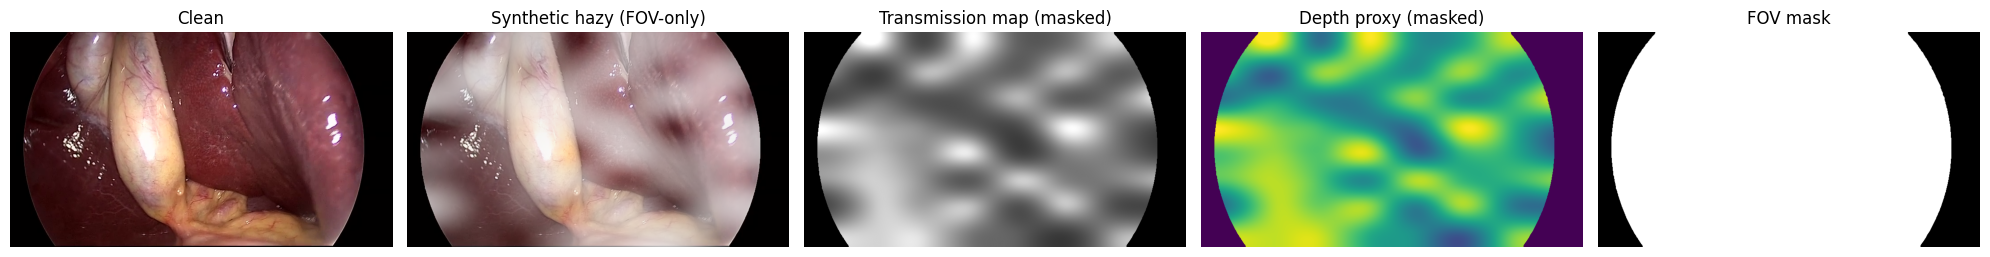

In [5]:
# %% CELL 4 — Synthetic haze visual check + pseudo-depth channel preview (FOV-aware)

def synth_haze(img_rgb, severity=0.5, seed=None):
    """
    img_rgb: float32 HxWx3 in [0,1]
    severity: 0 (clear) to 1 (heavy smoke)
    returns hazy image, transmission map, depth proxy, and the FOV mask used
    """
    rng = np.random.default_rng(seed)
    h, w, _ = img_rgb.shape
    fov_mask = get_fov_mask(img_rgb)

    small = rng.uniform(0.3, 1.0, size=(8, 8)).astype(np.float32)
    depth_proxy = cv2.resize(small, (w, h), interpolation=cv2.INTER_CUBIC)
    depth_proxy = np.clip(depth_proxy, 0.0, 1.0)

    beta = 0.5 + 2.5 * severity
    t = np.exp(-beta * (1.0 - depth_proxy))
    t = np.clip(t, 0.05, 1.0)[..., None]

    A = 0.85 + 0.1 * rng.uniform()
    hazy = img_rgb * t + A * (1 - t)
    hazy = np.clip(hazy, 0.0, 1.0).astype(np.float32)

    hazy[~fov_mask] = img_rgb[~fov_mask]
    return hazy, t[..., 0], depth_proxy, fov_mask


def load_and_haze_sample(path, severity=0.5, seed=0):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    hazy, t_map, depth_proxy, fov_mask = synth_haze(img, severity=severity, seed=seed)
    return img, hazy, t_map, depth_proxy, fov_mask


if len(sampled_paths) > 0:
    sample_path = sampled_paths[0]
    clean, hazy, t_map, depth_proxy, fov_mask = load_and_haze_sample(
        sample_path, severity=0.6, seed=1
    )

    t_display = np.where(fov_mask, t_map, 0)
    depth_display = np.where(fov_mask, depth_proxy, 0)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    axes[0].imshow(clean); axes[0].set_title("Clean")
    axes[1].imshow(hazy); axes[1].set_title("Synthetic hazy (FOV-only)")
    axes[2].imshow(t_display, cmap="gray"); axes[2].set_title("Transmission map (masked)")
    axes[3].imshow(depth_display, cmap="viridis"); axes[3].set_title("Depth proxy (masked)")
    axes[4].imshow(fov_mask, cmap="gray"); axes[4].set_title("FOV mask")
    for ax in axes: ax.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "synthetic_haze_preview_masked.png"), dpi=120)
    plt.show()

In [6]:
# %% CELL 5 — Monocular depth estimator scaffold (unchanged from before)
def load_midas_small():
    model_type = "MiDaS_small"
    midas = torch.hub.load("intel-isl/MiDaS", model_type)
    midas.to(DEVICE).eval()
    transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
    transform = transforms.small_transform
    return midas, transform

def estimate_depth(midas, transform, img_rgb_float01):
    img_uint8 = (img_rgb_float01 * 255).astype(np.uint8)
    inp = transform(img_uint8).to(DEVICE)
    with torch.no_grad():
        pred = midas(inp)
        pred = F.interpolate(pred.unsqueeze(1), size=img_rgb_float01.shape[:2],
                              mode="bicubic", align_corners=False).squeeze()
    depth = pred.cpu().numpy()
    depth = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)
    return depth

In [7]:
# %% CELL 6 — Edge-profiling harness (ONNX export bug fixed)
# The ModuleNotFoundError happens because newer torch defaults to the
# dynamo-based exporter, which needs 'onnxscript'. Force the legacy
# TorchScript-based exporter instead — it's lighter and doesn't need that dep.

class DummyDehazeNet(nn.Module):
    def __init__(self, in_ch=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 3, 3, padding=1),
        )
    def forward(self, x):
        return self.net(x)

def benchmark_latency(model, input_shape=(1, 3, 256, 256), n_runs=50, device="cpu"):
    model = model.to(device).eval()
    x = torch.randn(*input_shape).to(device)
    with torch.no_grad():
        for _ in range(5):
            model(x)
        t0 = time.time()
        for _ in range(n_runs):
            model(x)
        t1 = time.time()
    avg_ms = (t1 - t0) / n_runs * 1000
    n_params = sum(p.numel() for p in model.parameters())
    return {"avg_latency_ms": avg_ms, "n_params": n_params, "device": device}

def export_onnx(model, path, input_shape=(1, 3, 256, 256)):
    model.eval()
    dummy = torch.randn(*input_shape)
    try:
        torch.onnx.export(model, dummy, path, input_names=["input"],
                           output_names=["output"], opset_version=13, dynamo=False)
    except TypeError:
        # older torch versions don't accept the dynamo kwarg at all — fine, that's the legacy path anyway
        torch.onnx.export(model, dummy, path, input_names=["input"],
                           output_names=["output"], opset_version=13)
    return path

dummy_model = DummyDehazeNet(in_ch=3)
cpu_stats = benchmark_latency(dummy_model, device="cpu")
print("CPU latency (edge-proxy):", cpu_stats)

onnx_path = os.path.join(OUT_DIR, "dummy_dehaze.onnx")
export_onnx(dummy_model, onnx_path)
print("Exported ONNX to:", onnx_path)

with open(os.path.join(OUT_DIR, "day1_2_summary.json"), "w") as f:
    json.dump({"n_images_found": len(image_paths), "cpu_latency_stats": cpu_stats}, f, indent=2)

print("Day 1-2 artifacts saved to:", OUT_DIR)

CPU latency (edge-proxy): {'avg_latency_ms': 6.910519599914551, 'n_params': 3203, 'device': 'cpu'}


/tmp/ipykernel_58/3354988087.py:35: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, dummy, path, input_names=["input"],


Exported ONNX to: /kaggle/working/day1_2_outputs/dummy_dehaze.onnx
Day 1-2 artifacts saved to: /kaggle/working/day1_2_outputs


In [8]:
# %% Zip and get a direct download link
import shutil
from IPython.display import FileLink

zip_base = "/kaggle/working/day1_2_outputs"
shutil.make_archive(zip_base, 'zip', OUT_DIR)
FileLink(zip_base + ".zip")

/kaggle/working/day1_2_outputs.zip

In [9]:
# %% CELL 7 — Dark Channel Prior (DCP) dehazing, FOV-aware
# Classical, zero-training baseline — this is your "runs on anything" edge fallback.

def get_dark_channel(img, patch=15):
    min_c = np.min(img, axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (patch, patch))
    return cv2.erode(min_c, kernel)

def estimate_atmospheric_light(img, dark_channel, fov_mask, top_frac=0.001):
    """Pick the brightest pixels among the most-hazy dark-channel pixels, inside FOV only."""
    h, w = dark_channel.shape
    flat_dc = dark_channel.copy()
    flat_dc[~fov_mask] = -1  # exclude vignette from candidate selection
    n_pixels = max(int(fov_mask.sum() * top_frac), 10)
    flat_idx = np.argsort(flat_dc.reshape(-1))[-n_pixels:]
    flat_img = img.reshape(-1, 3)
    A = flat_img[flat_idx].max(axis=0)
    return A

def estimate_transmission(img, A, omega=0.95, patch=15):
    normed = img / (A + 1e-6)
    dark = get_dark_channel(normed, patch=patch)
    t = 1 - omega * dark
    return np.clip(t, 0.1, 1.0)

def guided_filter(guide, src, radius=40, eps=1e-3):
    guide = guide.astype(np.float32)
    src = src.astype(np.float32)
    mean_g = cv2.boxFilter(guide, -1, (radius, radius))
    mean_s = cv2.boxFilter(src, -1, (radius, radius))
    mean_gs = cv2.boxFilter(guide * src, -1, (radius, radius))
    cov_gs = mean_gs - mean_g * mean_s
    mean_gg = cv2.boxFilter(guide * guide, -1, (radius, radius))
    var_g = mean_gg - mean_g * mean_g
    a = cov_gs / (var_g + eps)
    b = mean_s - a * mean_g
    mean_a = cv2.boxFilter(a, -1, (radius, radius))
    mean_b = cv2.boxFilter(b, -1, (radius, radius))
    return mean_a * guide + mean_b

def dcp_dehaze(img_rgb, fov_mask, patch=15, omega=0.95, t0=0.1):
    dark = get_dark_channel(img_rgb, patch=patch)
    A = estimate_atmospheric_light(img_rgb, dark, fov_mask)
    t_raw = estimate_transmission(img_rgb, A, omega=omega, patch=patch)

    gray_guide = cv2.cvtColor((img_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    t_refined = guided_filter(gray_guide, t_raw)
    t_refined = np.clip(t_refined, t0, 1.0)[..., None]

    J = (img_rgb - A) / t_refined + A
    J = np.clip(J, 0.0, 1.0)
    J[~fov_mask] = img_rgb[~fov_mask]  # leave vignette untouched
    return J.astype(np.float32), t_refined[..., 0], A

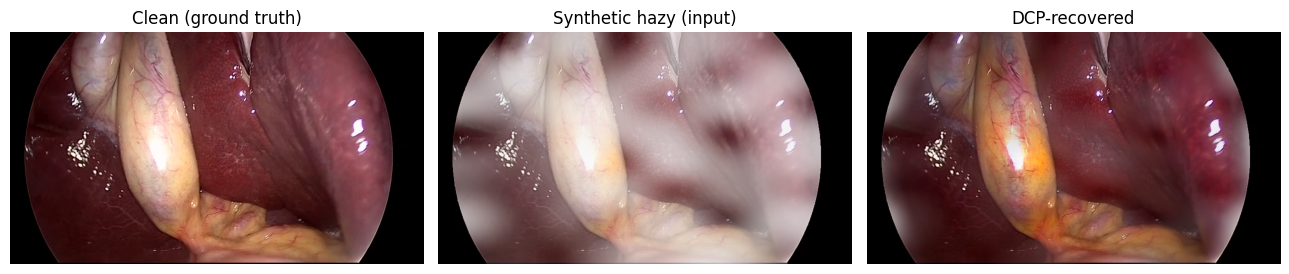

Estimated atmospheric light A: [0.98286915 0.9780068  0.9690962 ]


In [10]:
# %% CELL 8 — Qualitative check: DCP on synthetic hazy pairs (ground truth available)
sample_path = sampled_paths[0]  # from the corrected, mask-filtered sample list
clean, hazy, t_map, depth_proxy, fov_mask = load_and_haze_sample(sample_path, severity=0.6, seed=1)

recovered, t_est, A_est = dcp_dehaze(hazy, fov_mask)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(clean); axes[0].set_title("Clean (ground truth)")
axes[1].imshow(hazy); axes[1].set_title("Synthetic hazy (input)")
axes[2].imshow(recovered); axes[2].set_title("DCP-recovered")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "dcp_qualitative_check.png"), dpi=120)
plt.show()
print("Estimated atmospheric light A:", A_est)

In [11]:
# %% CELL 9 — PSNR/SSIM on synthetic pairs, stratified by severity bucket
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

def evaluate_dcp_on_synthetic(paths, severities_list, n_samples=60):
    results = []
    idxs = random.sample(range(len(paths)), min(n_samples, len(paths)))
    for i in idxs:
        p = paths[i]
        sev = severities_list[i] if severities_list else 0.5
        clean, hazy, _, _, fov_mask = load_and_haze_sample(p, severity=0.6, seed=i)
        recovered, _, _ = dcp_dehaze(hazy, fov_mask)

        ys, xs = np.where(fov_mask)
        y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
        c_crop = clean[y0:y1, x0:x1]
        r_crop = recovered[y0:y1, x0:x1]

        p_val = psnr(c_crop, r_crop, data_range=1.0)
        s_val = ssim(c_crop, r_crop, data_range=1.0, channel_axis=2)

        results.append({
            "path": p,
            "severity_proxy": float(sev),
            "psnr": float(p_val),
            "ssim": float(s_val),
        })
    return results

dcp_results = evaluate_dcp_on_synthetic(sampled_paths, severities if 'severities' in dir() else [])
psnr_vals = [r["psnr"] for r in dcp_results]
ssim_vals = [r["ssim"] for r in dcp_results]
print(f"DCP baseline — mean PSNR: {np.mean(psnr_vals):.2f} dB, mean SSIM: {np.mean(ssim_vals):.3f}")

with open(os.path.join(OUT_DIR, "dcp_eval_day4.json"), "w") as f:
    json.dump(dcp_results, f, indent=2)

DCP baseline — mean PSNR: 19.07 dB, mean SSIM: 0.838


In [12]:
# %% CELL 10 — DCP latency + Day 3-4 summary (dtype-safe)
def benchmark_dcp_latency(img_rgb, fov_mask, n_runs=20):
    t0 = time.time()
    for _ in range(n_runs):
        dcp_dehaze(img_rgb, fov_mask)
    t1 = time.time()
    return (t1 - t0) / n_runs * 1000  # ms per frame

dcp_ms = benchmark_dcp_latency(hazy, fov_mask)
print(f"DCP average latency: {dcp_ms:.2f} ms/frame (CPU, {hazy.shape[1]}x{hazy.shape[0]})")

with open(os.path.join(OUT_DIR, "day3_4_summary.json"), "w") as f:
    json.dump({
        "dcp_mean_psnr": float(np.mean(psnr_vals)),
        "dcp_mean_ssim": float(np.mean(ssim_vals)),
        "dcp_latency_ms": float(dcp_ms),
    }, f, indent=2)

print("Day 3-4 baseline: PSNR", round(float(np.mean(psnr_vals)), 2),
      "SSIM", round(float(np.mean(ssim_vals)), 3),
      "Latency", round(float(dcp_ms), 2), "ms")

DCP average latency: 109.84 ms/frame (CPU, 854x480)
Day 3-4 baseline: PSNR 19.07 SSIM 0.838 Latency 109.84 ms


In [13]:
# %% CELL 11 — PyTorch Dataset: on-the-fly synthetic (clean, hazy) pairs
from torch.utils.data import Dataset, DataLoader

class SyntheticHazeDataset(Dataset):
    """
    Wraps clean surgical frames and generates a synthetic hazy version on the fly.
    severity_range lets you sample varied haze intensity per training example,
    so the model doesn't overfit to one fixed severity.
    """
    def __init__(self, paths, crop_size=256, severity_range=(0.2, 0.9)):
        self.paths = paths
        self.crop_size = crop_size
        self.severity_range = severity_range

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

        # random resize-crop to a fixed training resolution
        h, w, _ = img.shape
        if h > self.crop_size and w > self.crop_size:
            top = np.random.randint(0, h - self.crop_size)
            left = np.random.randint(0, w - self.crop_size)
            img = img[top:top + self.crop_size, left:left + self.crop_size]
        else:
            img = cv2.resize(img, (self.crop_size, self.crop_size))

        severity = np.random.uniform(*self.severity_range)
        hazy, _, _, fov_mask = synth_haze(img, severity=severity, seed=None)

        # CHW float32 tensors
        clean_t = torch.from_numpy(img.transpose(2, 0, 1)).float()
        hazy_t = torch.from_numpy(hazy.transpose(2, 0, 1)).float()
        mask_t = torch.from_numpy(fov_mask.astype(np.float32))[None, ...]  # 1xHxW

        return hazy_t, clean_t, mask_t


# Train/val split at the VIDEO level, not the frame level — frames from the
# same video are highly correlated, so splitting by frame would leak
# near-duplicate scenes between train and val.
video_ids = list(by_video.keys())
random.seed(7)
random.shuffle(video_ids)
n_val_videos = max(1, int(0.15 * len(video_ids)))
val_video_ids = set(video_ids[:n_val_videos])
train_video_ids = set(video_ids[n_val_videos:])

def paths_for_videos(video_id_set):
    out = []
    for vid in video_id_set:
        out.extend(by_video[vid])
    return out

train_paths = paths_for_videos(train_video_ids)
val_paths = paths_for_videos(val_video_ids)
print(f"Train videos: {len(train_video_ids)} ({len(train_paths)} frames) | "
      f"Val videos: {len(val_video_ids)} ({len(val_paths)} frames)")

train_ds = SyntheticHazeDataset(train_paths, crop_size=256)
val_ds = SyntheticHazeDataset(val_paths, crop_size=256, severity_range=(0.5, 0.5))  # fixed severity for stable val comparison

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2)

Train videos: 86 (6880 frames) | Val videos: 15 (1200 frames)


In [14]:
# %% CELL 12 — Lightweight RGB-only dehazing CNN (AOD-Net-style)
# AOD-Net's trick: instead of predicting the clean image directly, predict a
# single parameter K and recover J = K * I - K + b, which is the same
# physical haze model as DCP but learned end-to-end. Small, fast, edge-friendly.

class AODNetLite(nn.Module):
    def __init__(self, in_ch=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 3, 1, padding=0)
        self.conv2 = nn.Conv2d(3, 3, 3, padding=1)
        self.conv3 = nn.Conv2d(6, 3, 5, padding=2)   # concat(conv1, conv2)
        self.conv4 = nn.Conv2d(6, 3, 7, padding=3)   # concat(conv2, conv3)
        self.conv5 = nn.Conv2d(12, 3, 3, padding=1)  # concat(conv1..conv4)
        self.relu = nn.ReLU(inplace=True)
        self.b = 1.0  # bias term in the haze model

    def forward(self, x):
        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        cat1 = torch.cat([x1, x2], dim=1)
        x3 = self.relu(self.conv3(cat1))
        cat2 = torch.cat([x2, x3], dim=1)
        x4 = self.relu(self.conv4(cat2))
        cat3 = torch.cat([x1, x2, x3, x4], dim=1)
        k = self.relu(self.conv5(cat3))

        # J = K * I - K + b  (elementwise), clamp K away from degenerate values
        k = torch.clamp(k, min=0.01)
        out = k * x - k + self.b
        return torch.clamp(out, 0.0, 1.0)

model_rgb = AODNetLite(in_ch=3).to(DEVICE)
n_params = sum(p.numel() for p in model_rgb.parameters())
print(f"AODNetLite (RGB-only) params: {n_params:,}")

AODNetLite (RGB-only) params: 1,761


In [17]:
!pip install -q pytorch-msssim

In [18]:
# %% CELL 13 — Loss, optimizer, training loop
from pytorch_msssim import ssim as ssim_loss_fn  # pip install pytorch-msssim if missing

def combined_loss(pred, target, mask, l1_weight=1.0, ssim_weight=0.2):
    """L1 (pixel fidelity) + SSIM (structural similarity), masked to FOV only."""
    mask3 = mask.repeat(1, 3, 1, 1)
    l1 = F.l1_loss(pred * mask3, target * mask3)
    s = 1 - ssim_loss_fn(pred * mask3, target * mask3, data_range=1.0, size_average=True)
    return l1_weight * l1 + ssim_weight * s, l1.item(), s.item()

optimizer = torch.optim.Adam(model_rgb.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

def run_epoch(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, total_l1, total_ssim, n_batches = 0.0, 0.0, 0.0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for hazy, clean, mask in loader:
            hazy, clean, mask = hazy.to(DEVICE), clean.to(DEVICE), mask.to(DEVICE)
            pred = model(hazy)
            loss, l1_v, ssim_v = combined_loss(pred, clean, mask)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item(); total_l1 += l1_v; total_ssim += ssim_v
            n_batches += 1
    return total_loss / n_batches, total_l1 / n_batches, total_ssim / n_batches

In [19]:
# %% CELL 14 — Day 5 sanity run: a handful of epochs to confirm the pipeline actually learns
# Not the full Day 5-7 training budget — just enough to catch bugs before committing GPU hours.

N_SANITY_EPOCHS = 5
history = []

for epoch in range(N_SANITY_EPOCHS):
    train_loss, train_l1, train_ssim_l = run_epoch(model_rgb, train_loader, optimizer, train=True)
    val_loss, val_l1, val_ssim_l = run_epoch(model_rgb, val_loader, train=False)
    scheduler.step()
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    print(f"Epoch {epoch+1}/{N_SANITY_EPOCHS} — train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

# Sanity check: loss should trend down. If it's flat or NaN, stop here and debug
# before scaling up epochs — common culprits: severity_range too extreme,
# learning rate too high, or the FOV mask zeroing out too much of the image.

with open(os.path.join(OUT_DIR, "day5_sanity_history.json"), "w") as f:
    json.dump(history, f, indent=2)

Epoch 1/5 — train_loss: 0.1608 | val_loss: 0.1168
Epoch 2/5 — train_loss: 0.1274 | val_loss: 0.1071
Epoch 3/5 — train_loss: 0.1153 | val_loss: 0.1103
Epoch 4/5 — train_loss: 0.1131 | val_loss: 0.1012
Epoch 5/5 — train_loss: 0.1105 | val_loss: 0.1000


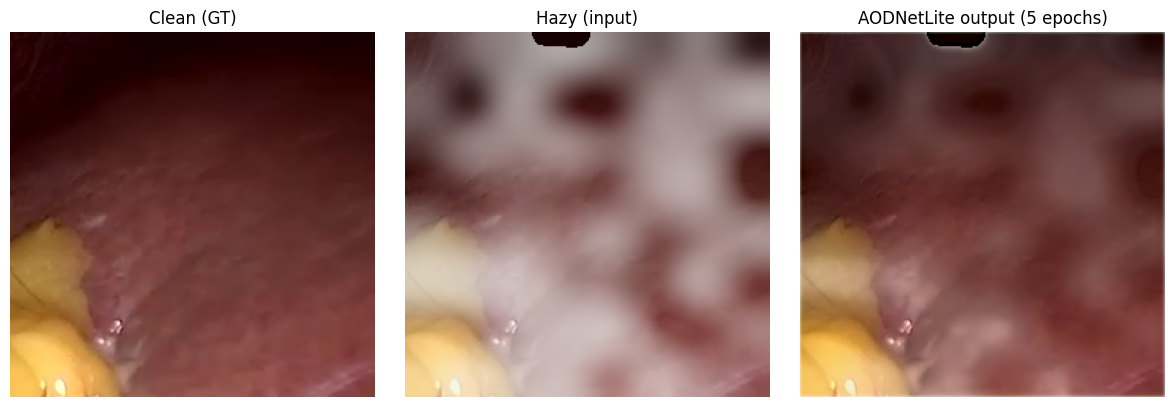

In [20]:
# %% CELL 15 — Visual sanity check on a validation sample
model_rgb.eval()
hazy_sample, clean_sample, mask_sample = val_ds[0]
with torch.no_grad():
    pred_sample = model_rgb(hazy_sample.unsqueeze(0).to(DEVICE)).cpu().squeeze(0)

def to_display(t):
    return t.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(to_display(clean_sample)); axes[0].set_title("Clean (GT)")
axes[1].imshow(to_display(hazy_sample)); axes[1].set_title("Hazy (input)")
axes[2].imshow(to_display(pred_sample)); axes[2].set_title("AODNetLite output (5 epochs)")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "day5_sanity_visual.png"), dpi=120)
plt.show()

In [21]:
# %% CELL 16 — Full training run for the RGB-only branch, with checkpointing
N_EPOCHS = 30
best_val_loss = float("inf")
ckpt_path_rgb = os.path.join(OUT_DIR, "aodnet_rgb_only_best.pt")
full_history_rgb = []

# fresh model/optimizer so Day 6's real run isn't contaminated by the 5-epoch sanity weights
model_rgb = AODNetLite(in_ch=3).to(DEVICE)
optimizer = torch.optim.Adam(model_rgb.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

for epoch in range(N_EPOCHS):
    train_loss, train_l1, train_ssim_l = run_epoch(model_rgb, train_loader, optimizer, train=True)
    val_loss, val_l1, val_ssim_l = run_epoch(model_rgb, val_loader, train=False)
    scheduler.step()

    full_history_rgb.append({
        "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
        "train_l1": train_l1, "val_l1": val_l1,
        "train_ssim_loss": train_ssim_l, "val_ssim_loss": val_ssim_l,
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_rgb.state_dict(), ckpt_path_rgb)

    if epoch % 5 == 0 or epoch == N_EPOCHS - 1:
        print(f"Epoch {epoch+1}/{N_EPOCHS} — train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}"
              f"{'  <- best' if val_loss == best_val_loss else ''}")

with open(os.path.join(OUT_DIR, "rgb_only_training_history.json"), "w") as f:
    json.dump(full_history_rgb, f, indent=2)

print(f"Best RGB-only val_loss: {best_val_loss:.4f}, saved to {ckpt_path_rgb}")

Epoch 1/30 — train_loss: 0.1653 | val_loss: 0.1215  <- best
Epoch 6/30 — train_loss: 0.1151 | val_loss: 0.1040  <- best
Epoch 11/30 — train_loss: 0.1094 | val_loss: 0.1028
Epoch 16/30 — train_loss: 0.1074 | val_loss: 0.1016
Epoch 21/30 — train_loss: 0.1061 | val_loss: 0.1051
Epoch 26/30 — train_loss: 0.1052 | val_loss: 0.1043
Epoch 30/30 — train_loss: 0.1044 | val_loss: 0.1024
Best RGB-only val_loss: 0.0980, saved to /kaggle/working/day1_2_outputs/aodnet_rgb_only_best.pt


In [22]:
# %% CELL 17 — Precompute + cache monocular depth maps (don't run MiDaS live every epoch)
# Running MiDaS inside the DataLoader per-sample, every epoch, would dominate
# training time for no benefit — depth from a CLEAN reference frame is static
# per image, so compute it once and cache to disk.

midas, midas_transform = load_midas_small()  # requires internet ON (Cell 5)

def precompute_depth_cache(paths, cache_dir):
    os.makedirs(cache_dir, exist_ok=True)
    cache_map = {}
    for i, p in enumerate(paths):
        cache_file = os.path.join(cache_dir, f"{i:06d}.npy")
        if not os.path.exists(cache_file):
            img = cv2.imread(p)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            depth = estimate_depth(midas, midas_transform, img)
            np.save(cache_file, depth.astype(np.float32))
        cache_map[p] = cache_file
        if i % 200 == 0:
            print(f"  depth cache: {i}/{len(paths)}")
    return cache_map

DEPTH_CACHE_DIR = "/kaggle/working/depth_cache"
print("Precomputing depth for train set...")
train_depth_cache = precompute_depth_cache(train_paths, DEPTH_CACHE_DIR)
print("Precomputing depth for val set...")
val_depth_cache = precompute_depth_cache(val_paths, DEPTH_CACHE_DIR)

depth_cache_map = {**train_depth_cache, **val_depth_cache}
print(f"Cached depth maps for {len(depth_cache_map)} frames")

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /root/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:00<00:00, 383MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Precomputing depth for train set...
  depth cache: 0/6880
  depth cache: 200/6880
  depth cache: 400/6880
  depth cache: 600/6880
  depth cache: 800/6880
  depth cache: 1000/6880
  depth cache: 1200/6880
  depth cache: 1400/6880
  depth cache: 1600/6880
  depth cache: 1800/6880
  depth cache: 2000/6880
  depth cache: 2200/6880
  depth cache: 2400/6880
  depth cache: 2600/6880
  depth cache: 2800/6880
  depth cache: 3000/6880
  depth cache: 3200/6880
  depth cache: 3400/6880
  depth cache: 3600/6880
  depth cache: 3800/6880
  depth cache: 4000/6880
  depth cache: 4200/6880
  depth cache: 4400/6880
  depth cache: 4600/6880
  depth cache: 4800/6880
  depth cache: 5000/6880
  depth cache: 5200/6880
  depth cache: 5400/6880
  depth cache: 5600/6880
  depth cache: 5800/6880
  depth cache: 6000/6880
  depth cache: 6200/6880
  depth cache: 6400/6880
  depth cache: 6600/6880
  depth cache: 6800/6880
Precomputing depth for val set...
  depth cache: 0/1200
  depth cache: 200/1200
  depth cache: 4

In [23]:
# %% CELL 18 — Depth-augmented dataset: RGB + estimated depth as a 4th channel
class DepthFusionHazeDataset(Dataset):
    """
    Same synthetic-haze pairing as before, but the network input is
    RGB(hazy) concatenated with a pre-cached monocular depth estimate —
    this is the 'RGB+depth-fusion' branch for the sensor-fusion comparison.
    """
    def __init__(self, paths, depth_cache_map, crop_size=256, severity_range=(0.2, 0.9)):
        self.paths = paths
        self.depth_cache_map = depth_cache_map
        self.crop_size = crop_size
        self.severity_range = severity_range

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        depth = np.load(self.depth_cache_map[path])  # HxW, normalized 0-1, full resolution

        h, w, _ = img.shape
        if h > self.crop_size and w > self.crop_size:
            top = np.random.randint(0, h - self.crop_size)
            left = np.random.randint(0, w - self.crop_size)
            img = img[top:top + self.crop_size, left:left + self.crop_size]
            depth = depth[top:top + self.crop_size, left:left + self.crop_size]
        else:
            img = cv2.resize(img, (self.crop_size, self.crop_size))
            depth = cv2.resize(depth, (self.crop_size, self.crop_size))

        severity = np.random.uniform(*self.severity_range)
        hazy, _, _, fov_mask = synth_haze(img, severity=severity, seed=None)

        depth_masked = np.where(fov_mask, depth, 0.0).astype(np.float32)

        clean_t = torch.from_numpy(img.transpose(2, 0, 1)).float()
        hazy_t = torch.from_numpy(hazy.transpose(2, 0, 1)).float()
        depth_t = torch.from_numpy(depth_masked)[None, ...]  # 1xHxW
        input_t = torch.cat([hazy_t, depth_t], dim=0)        # 4xHxW
        mask_t = torch.from_numpy(fov_mask.astype(np.float32))[None, ...]

        return input_t, clean_t, mask_t


train_ds_depth = DepthFusionHazeDataset(train_paths, depth_cache_map, crop_size=256)
val_ds_depth = DepthFusionHazeDataset(val_paths, depth_cache_map, crop_size=256, severity_range=(0.5, 0.5))

train_loader_depth = DataLoader(train_ds_depth, batch_size=8, shuffle=True, num_workers=2, drop_last=True)
val_loader_depth = DataLoader(val_ds_depth, batch_size=8, shuffle=False, num_workers=2)

In [24]:
# %% CELL 12 — Lightweight dehazing CNN, works for both in_ch=3 and in_ch=4
class AODNetLite(nn.Module):
    def __init__(self, in_ch=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 3, 1, padding=0)
        self.conv2 = nn.Conv2d(3, 3, 3, padding=1)
        self.conv3 = nn.Conv2d(6, 3, 5, padding=2)
        self.conv4 = nn.Conv2d(6, 3, 7, padding=3)
        self.conv5 = nn.Conv2d(12, 3, 3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.b = 1.0

    def forward(self, x):
        rgb = x[:, :3, :, :]  # haze equation applies to RGB only, regardless of extra input channels

        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        cat1 = torch.cat([x1, x2], dim=1)
        x3 = self.relu(self.conv3(cat1))
        cat2 = torch.cat([x2, x3], dim=1)
        x4 = self.relu(self.conv4(cat2))
        cat3 = torch.cat([x1, x2, x3, x4], dim=1)
        k = self.relu(self.conv5(cat3))

        k = torch.clamp(k, min=0.01)
        out = k * rgb - k + self.b   # rgb, not x — this is the fix
        return torch.clamp(out, 0.0, 1.0)

In [25]:
test_model = AODNetLite(in_ch=4).to(DEVICE)
test_out = test_model(torch.randn(2, 4, 256, 256).to(DEVICE))
print(test_out.shape)  # should print torch.Size([2, 3, 256, 256]) with no error

torch.Size([2, 3, 256, 256])


In [27]:
# %% CELL 12 — Lightweight dehazing CNN, works for both in_ch=3 and in_ch=4
class AODNetLite(nn.Module):
    def __init__(self, in_ch=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 3, 1, padding=0)
        self.conv2 = nn.Conv2d(3, 3, 3, padding=1)
        self.conv3 = nn.Conv2d(6, 3, 5, padding=2)
        self.conv4 = nn.Conv2d(6, 3, 7, padding=3)
        self.conv5 = nn.Conv2d(12, 3, 3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.b = 1.0

    def forward(self, x):
        rgb = x[:, :3, :, :]  # haze equation applies to RGB only, regardless of extra input channels

        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        cat1 = torch.cat([x1, x2], dim=1)
        x3 = self.relu(self.conv3(cat1))
        cat2 = torch.cat([x2, x3], dim=1)
        x4 = self.relu(self.conv4(cat2))
        cat3 = torch.cat([x1, x2, x3, x4], dim=1)
        k = self.relu(self.conv5(cat3))

        k = torch.clamp(k, min=0.01)
        out = k * rgb - k + self.b   # rgb, not x — this is the fix
        return torch.clamp(out, 0.0, 1.0)

In [31]:
# %% CELL 12 — Lightweight dehazing CNN, works for both in_ch=3 and in_ch=4
class AODNetLite(nn.Module):
    def __init__(self, in_ch=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 3, 1, padding=0)
        self.conv2 = nn.Conv2d(3, 3, 3, padding=1)
        self.conv3 = nn.Conv2d(6, 3, 5, padding=2)
        self.conv4 = nn.Conv2d(6, 3, 7, padding=3)
        self.conv5 = nn.Conv2d(12, 3, 3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.b = 1.0

    def forward(self, x):
        rgb = x[:, :3, :, :]  # haze equation applies to RGB only, regardless of extra input channels

        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        cat1 = torch.cat([x1, x2], dim=1)
        x3 = self.relu(self.conv3(cat1))
        cat2 = torch.cat([x2, x3], dim=1)
        x4 = self.relu(self.conv4(cat2))
        cat3 = torch.cat([x1, x2, x3, x4], dim=1)
        k = self.relu(self.conv5(cat3))

        k = torch.clamp(k, min=0.01)
        out = k * rgb - k + self.b   # rgb, not x — this is the fix
        return torch.clamp(out, 0.0, 1.0)

In [32]:
# %% CELL 17 — Precompute + cache monocular depth maps
midas, midas_transform = load_midas_small()  # requires internet ON

def precompute_depth_cache(paths, cache_dir):
    os.makedirs(cache_dir, exist_ok=True)
    cache_map = {}
    for i, p in enumerate(paths):
        cache_file = os.path.join(cache_dir, f"{i:06d}.npy")
        if not os.path.exists(cache_file):
            img = cv2.imread(p)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            depth = estimate_depth(midas, midas_transform, img)
            np.save(cache_file, depth.astype(np.float32))
        cache_map[p] = cache_file
        if i % 200 == 0:
            print(f"  depth cache: {i}/{len(paths)}")
    return cache_map

DEPTH_CACHE_DIR = "/kaggle/working/depth_cache"
print("Precomputing depth for train set...")
train_depth_cache = precompute_depth_cache(train_paths, DEPTH_CACHE_DIR)
print("Precomputing depth for val set...")
val_depth_cache = precompute_depth_cache(val_paths, DEPTH_CACHE_DIR)

depth_cache_map = {**train_depth_cache, **val_depth_cache}
print(f"Cached depth maps for {len(depth_cache_map)} frames")

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


Loading weights:  None
Precomputing depth for train set...
  depth cache: 0/6880
  depth cache: 200/6880
  depth cache: 400/6880
  depth cache: 600/6880
  depth cache: 800/6880
  depth cache: 1000/6880
  depth cache: 1200/6880
  depth cache: 1400/6880
  depth cache: 1600/6880
  depth cache: 1800/6880
  depth cache: 2000/6880
  depth cache: 2200/6880
  depth cache: 2400/6880
  depth cache: 2600/6880
  depth cache: 2800/6880
  depth cache: 3000/6880
  depth cache: 3200/6880
  depth cache: 3400/6880
  depth cache: 3600/6880
  depth cache: 3800/6880
  depth cache: 4000/6880
  depth cache: 4200/6880
  depth cache: 4400/6880
  depth cache: 4600/6880
  depth cache: 4800/6880
  depth cache: 5000/6880
  depth cache: 5200/6880
  depth cache: 5400/6880
  depth cache: 5600/6880
  depth cache: 5800/6880
  depth cache: 6000/6880
  depth cache: 6200/6880
  depth cache: 6400/6880
  depth cache: 6600/6880
  depth cache: 6800/6880
Precomputing depth for val set...
  depth cache: 0/1200
  depth cache: 20

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


In [33]:
# %% CELL 18 — Depth-augmented dataset (RGB + estimated depth as 4th channel)
class DepthFusionHazeDataset(Dataset):
    def __init__(self, paths, depth_cache_map, crop_size=256, severity_range=(0.2, 0.9)):
        self.paths = paths
        self.depth_cache_map = depth_cache_map
        self.crop_size = crop_size
        self.severity_range = severity_range

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        depth = np.load(self.depth_cache_map[path])

        h, w, _ = img.shape
        if h > self.crop_size and w > self.crop_size:
            top = np.random.randint(0, h - self.crop_size)
            left = np.random.randint(0, w - self.crop_size)
            img = img[top:top + self.crop_size, left:left + self.crop_size]
            depth = depth[top:top + self.crop_size, left:left + self.crop_size]
        else:
            img = cv2.resize(img, (self.crop_size, self.crop_size))
            depth = cv2.resize(depth, (self.crop_size, self.crop_size))

        severity = np.random.uniform(*self.severity_range)
        hazy, _, _, fov_mask = synth_haze(img, severity=severity, seed=None)
        depth_masked = np.where(fov_mask, depth, 0.0).astype(np.float32)

        clean_t = torch.from_numpy(img.transpose(2, 0, 1)).float()
        hazy_t = torch.from_numpy(hazy.transpose(2, 0, 1)).float()
        depth_t = torch.from_numpy(depth_masked)[None, ...]
        input_t = torch.cat([hazy_t, depth_t], dim=0)
        mask_t = torch.from_numpy(fov_mask.astype(np.float32))[None, ...]

        return input_t, clean_t, mask_t


train_ds_depth = DepthFusionHazeDataset(train_paths, depth_cache_map, crop_size=256)
val_ds_depth = DepthFusionHazeDataset(val_paths, depth_cache_map, crop_size=256, severity_range=(0.5, 0.5))

train_loader_depth = DataLoader(train_ds_depth, batch_size=8, shuffle=True, num_workers=2, drop_last=True)
val_loader_depth = DataLoader(val_ds_depth, batch_size=8, shuffle=False, num_workers=2)

In [34]:
# %% CELL 12 (RE-RUN THIS — corrected class, confirm before proceeding)
class AODNetLite(nn.Module):
    def __init__(self, in_ch=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 3, 1, padding=0)
        self.conv2 = nn.Conv2d(3, 3, 3, padding=1)
        self.conv3 = nn.Conv2d(6, 3, 5, padding=2)
        self.conv4 = nn.Conv2d(6, 3, 7, padding=3)
        self.conv5 = nn.Conv2d(12, 3, 3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.b = 1.0

    def forward(self, x):
        rgb = x[:, :3, :, :]
        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        cat1 = torch.cat([x1, x2], dim=1)
        x3 = self.relu(self.conv3(cat1))
        cat2 = torch.cat([x2, x3], dim=1)
        x4 = self.relu(self.conv4(cat2))
        cat3 = torch.cat([x1, x2, x3, x4], dim=1)
        k = self.relu(self.conv5(cat3))
        k = torch.clamp(k, min=0.01)
        out = k * rgb - k + self.b
        return torch.clamp(out, 0.0, 1.0)

# shape check — must print torch.Size([2, 3, 256, 256]) before continuing
_test = AODNetLite(in_ch=4).to(DEVICE)
_out = _test(torch.randn(2, 4, 256, 256).to(DEVICE))
print("Shape check:", _out.shape)
del _test, _out

Shape check: torch.Size([2, 3, 256, 256])


In [35]:
# %% CELL 19 — Depth-fusion model + training run (RUN THIS FULLY, watch for NaN)
N_EPOCHS = 30  # confirm this matches what Cell 16 used

model_depth = AODNetLite(in_ch=4).to(DEVICE)
n_params_depth = sum(p.numel() for p in model_depth.parameters())
print(f"AODNetLite (RGB+depth) params: {n_params_depth:,} "
      f"(RGB-only had {sum(p.numel() for p in model_rgb.parameters()):,})")

optimizer_depth = torch.optim.Adam(model_depth.parameters(), lr=1e-3)
scheduler_depth = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_depth, T_max=N_EPOCHS)

best_val_loss_depth = float("inf")
ckpt_path_depth = os.path.join(OUT_DIR, "aodnet_depth_fusion_best.pt")
full_history_depth = []

for epoch in range(N_EPOCHS):
    train_loss, train_l1, train_ssim_l = run_epoch(model_depth, train_loader_depth, optimizer_depth, train=True)
    val_loss, val_l1, val_ssim_l = run_epoch(model_depth, val_loader_depth, train=False)
    scheduler_depth.step()

    if np.isnan(train_loss) or np.isnan(val_loss):
        print(f"NaN loss detected at epoch {epoch+1} — stopping early. "
              f"Retry with a lower learning rate (e.g. 5e-4).")
        break

    full_history_depth.append({
        "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
        "train_l1": train_l1, "val_l1": val_l1,
    })

    if val_loss < best_val_loss_depth:
        best_val_loss_depth = val_loss
        torch.save(model_depth.state_dict(), ckpt_path_depth)

    if epoch % 5 == 0 or epoch == N_EPOCHS - 1:
        print(f"[depth-fusion] Epoch {epoch+1}/{N_EPOCHS} — train_loss: {train_loss:.4f} | "
              f"val_loss: {val_loss:.4f}{'  <- best' if val_loss == best_val_loss_depth else ''}")

with open(os.path.join(OUT_DIR, "depth_fusion_training_history.json"), "w") as f:
    json.dump(full_history_depth, f, indent=2)

if os.path.exists(ckpt_path_depth):
    print(f"Best depth-fusion val_loss: {best_val_loss_depth:.4f}, saved to {ckpt_path_depth}")
else:
    print("WARNING: no checkpoint was saved — training likely NaN'd on epoch 0. Check the printout above.")

AODNetLite (RGB+depth) params: 1,764 (RGB-only had 1,761)
[depth-fusion] Epoch 1/30 — train_loss: 0.1604 | val_loss: 0.1205  <- best
[depth-fusion] Epoch 6/30 — train_loss: 0.1136 | val_loss: 0.1150
[depth-fusion] Epoch 11/30 — train_loss: 0.1123 | val_loss: 0.1187
[depth-fusion] Epoch 16/30 — train_loss: 0.1109 | val_loss: 0.1069
[depth-fusion] Epoch 21/30 — train_loss: 0.1090 | val_loss: 0.1060
[depth-fusion] Epoch 26/30 — train_loss: 0.1066 | val_loss: 0.1094
[depth-fusion] Epoch 30/30 — train_loss: 0.1056 | val_loss: 0.1075
Best depth-fusion val_loss: 0.1044, saved to /kaggle/working/day1_2_outputs/aodnet_depth_fusion_best.pt


In [36]:
model_rgb.load_state_dict(torch.load(ckpt_path_rgb))
model_depth.load_state_dict(torch.load(ckpt_path_depth))

model_rgb = model_rgb.to(DEVICE)
model_depth = model_depth.to(DEVICE)

In [37]:
# %% CELL 21 — Quantitative comparison (with the checkpoint guard)
for name, path in [("RGB-only", ckpt_path_rgb), ("RGB+depth", ckpt_path_depth)]:
    if not os.path.exists(path):
        raise RuntimeError(f"{name} checkpoint not found at {path}. Re-run Cell 19 and confirm it saved.")
    print(f"{name} checkpoint OK: {path}")

model_rgb.load_state_dict(torch.load(ckpt_path_rgb))
model_depth.load_state_dict(torch.load(ckpt_path_depth))

def evaluate_model_on_synthetic(model, paths, depth_cache_map=None, n_samples=60, fixed_severity=0.6):
    model.eval()
    results = []
    idxs = random.sample(range(len(paths)), min(n_samples, len(paths)))
    with torch.no_grad():
        for i in idxs:
            p = paths[i]
            img = cv2.imread(p)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            img_r = cv2.resize(img, (256, 256))
            hazy, _, _, fov_mask = synth_haze(img_r, severity=fixed_severity, seed=i)

            hazy_t = torch.from_numpy(hazy.transpose(2, 0, 1)).float().unsqueeze(0)
            if depth_cache_map is not None:
                depth = np.load(depth_cache_map[p])
                depth_r = cv2.resize(depth, (256, 256))
                depth_masked = np.where(fov_mask, depth_r, 0.0).astype(np.float32)
                depth_t = torch.from_numpy(depth_masked)[None, None, ...].float()
                inp_t = torch.cat([hazy_t, depth_t], dim=1)
            else:
                inp_t = hazy_t

            pred = model(inp_t.to(DEVICE)).cpu().squeeze(0).permute(1, 2, 0).numpy()
            ys, xs = np.where(fov_mask)
            y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
            c_crop = img_r[y0:y1, x0:x1]
            r_crop = pred[y0:y1, x0:x1]

            p_val = float(psnr(c_crop, r_crop, data_range=1.0))
            s_val = float(ssim(c_crop, r_crop, data_range=1.0, channel_axis=2))
            results.append({"path": p, "psnr": p_val, "ssim": s_val})
    return results

rgb_results = evaluate_model_on_synthetic(model_rgb, val_paths, depth_cache_map=None)
depth_results = evaluate_model_on_synthetic(model_depth, val_paths, depth_cache_map=depth_cache_map)

rgb_psnr = float(np.mean([r["psnr"] for r in rgb_results]))
rgb_ssim = float(np.mean([r["ssim"] for r in rgb_results]))
depth_psnr = float(np.mean([r["psnr"] for r in depth_results]))
depth_ssim = float(np.mean([r["ssim"] for r in depth_results]))

print(f"RGB-only     — PSNR: {rgb_psnr:.2f} dB, SSIM: {rgb_ssim:.3f}")
print(f"RGB+depth    — PSNR: {depth_psnr:.2f} dB, SSIM: {depth_ssim:.3f}")
print(f"DCP baseline — PSNR: {np.mean(psnr_vals):.2f} dB, SSIM: {np.mean(ssim_vals):.3f}  (from Day 3-4)")

RGB-only checkpoint OK: /kaggle/working/day1_2_outputs/aodnet_rgb_only_best.pt
RGB+depth checkpoint OK: /kaggle/working/day1_2_outputs/aodnet_depth_fusion_best.pt
RGB-only     — PSNR: 19.79 dB, SSIM: 0.823
RGB+depth    — PSNR: 19.49 dB, SSIM: 0.807
DCP baseline — PSNR: 19.07 dB, SSIM: 0.838  (from Day 3-4)


In [38]:
# %% CELL 22 — Inference-cost comparison (MiDaS overhead exposed)
def benchmark_full_pipeline_latency(rgb_model, depth_model, midas_model, midas_transform,
                                     input_shape=(1, 3, 256, 256), n_runs=20, device="cpu"):
    rgb_model = rgb_model.to(device).eval()
    depth_model = depth_model.to(device).eval()
    midas_model = midas_model.to(device).eval()
    dummy_rgb = torch.randn(*input_shape).to(device)
    dummy_img_uint8 = np.random.randint(0, 255, (256, 256, 3), dtype=np.uint8)

    with torch.no_grad():
        for _ in range(3): rgb_model(dummy_rgb)
        t0 = time.time()
        for _ in range(n_runs): rgb_model(dummy_rgb)
        rgb_only_ms = (time.time() - t0) / n_runs * 1000

        for _ in range(3):
            inp = midas_transform(dummy_img_uint8).to(device)
            midas_model(inp)
        t0 = time.time()
        for _ in range(n_runs):
            inp = midas_transform(dummy_img_uint8).to(device)
            _ = midas_model(inp)
        midas_ms = (time.time() - t0) / n_runs * 1000

        dummy_4ch = torch.randn(1, 4, 256, 256).to(device)
        for _ in range(3): depth_model(dummy_4ch)
        t0 = time.time()
        for _ in range(n_runs): depth_model(dummy_4ch)
        depth_net_ms = (time.time() - t0) / n_runs * 1000

    return {
        "rgb_only_total_ms": rgb_only_ms,
        "depth_fusion_dehazenet_only_ms": depth_net_ms,
        "midas_depth_estimation_ms": midas_ms,
        "depth_fusion_TOTAL_ms": depth_net_ms + midas_ms,
    }

latency_comparison = benchmark_full_pipeline_latency(model_rgb, model_depth, midas, midas_transform)
print(json.dumps(latency_comparison, indent=2))

{
  "rgb_only_total_ms": 13.754010200500488,
  "depth_fusion_dehazenet_only_ms": 13.348281383514404,
  "midas_depth_estimation_ms": 140.4622197151184,
  "depth_fusion_TOTAL_ms": 153.8105010986328
}


In [41]:
model_rgb = model_rgb.to(DEVICE)
model_depth = model_depth.to(DEVICE)

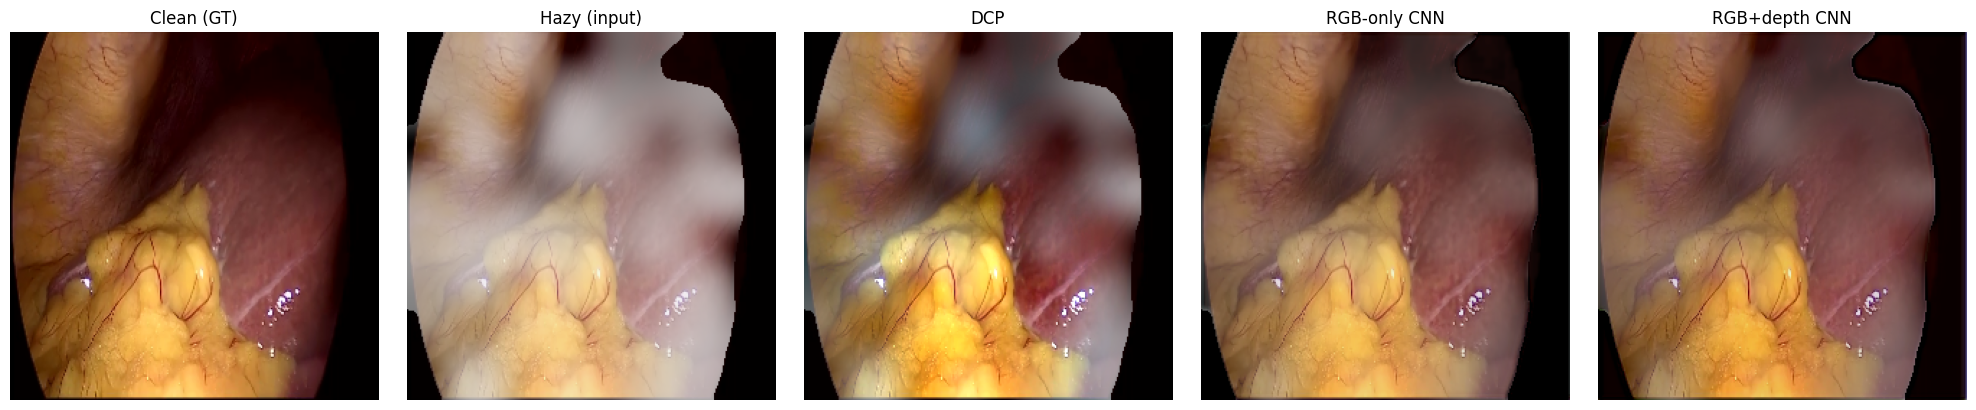

In [42]:
# %% CELL 23 — Qualitative side-by-side: DCP vs RGB-only vs RGB+depth
sample_path = val_paths[0]
img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
img_r = cv2.resize(img, (256, 256))
hazy, _, _, fov_mask = synth_haze(img_r, severity=0.6, seed=99)

dcp_out, _, _ = dcp_dehaze(hazy, fov_mask)

hazy_t = torch.from_numpy(hazy.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)
with torch.no_grad():
    rgb_out = model_rgb(hazy_t).cpu().squeeze(0).permute(1, 2, 0).numpy()

depth = np.load(depth_cache_map[sample_path])
depth_r = cv2.resize(depth, (256, 256))
depth_masked = np.where(fov_mask, depth_r, 0.0).astype(np.float32)
depth_t = torch.from_numpy(depth_masked)[None, None, ...].float()
inp_t = torch.cat([hazy_t.cpu(), depth_t], dim=1).to(DEVICE)
with torch.no_grad():
    depth_out = model_depth(inp_t).cpu().squeeze(0).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
titles = ["Clean (GT)", "Hazy (input)", "DCP", "RGB-only CNN", "RGB+depth CNN"]
imgs = [img_r, hazy, dcp_out, rgb_out, depth_out]
for ax, im, title in zip(axes, imgs, titles):
    ax.imshow(np.clip(im, 0, 1)); ax.set_title(title); ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "day7_qualitative_comparison.png"), dpi=120)
plt.show()

In [43]:
# %% CELL 24 — Day 7 summary
day7_summary = {
    "dcp":        {"psnr": float(np.mean(psnr_vals)), "ssim": float(np.mean(ssim_vals)),
                    "latency_ms": float(dcp_ms)},
    "rgb_only":   {"psnr": rgb_psnr, "ssim": rgb_ssim,
                    "params": int(sum(p.numel() for p in model_rgb.parameters())),
                    "latency_ms": float(latency_comparison["rgb_only_total_ms"])},
    "rgb_depth":  {"psnr": depth_psnr, "ssim": depth_ssim,
                    "params": int(n_params_depth),
                    "dehazenet_latency_ms": float(latency_comparison["depth_fusion_dehazenet_only_ms"]),
                    "midas_latency_ms": float(latency_comparison["midas_depth_estimation_ms"]),
                    "total_latency_ms": float(latency_comparison["depth_fusion_TOTAL_ms"])},
}
print(json.dumps(day7_summary, indent=2))

with open(os.path.join(OUT_DIR, "day7_summary.json"), "w") as f:
    json.dump(day7_summary, f, indent=2)

{
  "dcp": {
    "psnr": 19.07366461577317,
    "ssim": 0.8380814224481583,
    "latency_ms": 109.8381757736206
  },
  "rgb_only": {
    "psnr": 19.789195376234037,
    "ssim": 0.8234593470891317,
    "params": 1761,
    "latency_ms": 13.754010200500488
  },
  "rgb_depth": {
    "psnr": 19.494622746124858,
    "ssim": 0.8068580468495686,
    "params": 1764,
    "dehazenet_latency_ms": 13.348281383514404,
    "midas_latency_ms": 140.4622197151184,
    "total_latency_ms": 153.8105010986328
  }
}


In [45]:
# %% CELL 25 — Day 8: INT8 dynamic quantization on both trained models
import torch.quantization as tq

def quantize_model_int8(model):
    model_cpu = model.to("cpu").eval()
    quantized = tq.quantize_dynamic(
        model_cpu, {nn.Conv2d}, dtype=torch.qint8
    )
    return quantized

# Note: dynamic quantization on Conv2d has limited effect in PyTorch (it's really
# built for Linear/LSTM layers) — for a fair edge story you'd normally go through
# ONNX + onnxruntime static quantization instead. Do both here so the comparison
# is honest about what each method actually achieves.

model_rgb_int8_dynamic = quantize_model_int8(model_rgb)
model_depth_int8_dynamic = quantize_model_int8(model_depth)

def get_model_size_mb(model):
    torch.save(model.state_dict(), "/tmp/tmp_model.pt")
    size_mb = os.path.getsize("/tmp/tmp_model.pt") / (1024 * 1024)
    os.remove("/tmp/tmp_model.pt")
    return size_mb

print("RGB-only   FP32 size:", round(get_model_size_mb(model_rgb), 4), "MB")
print("RGB-only   INT8(dyn) size:", round(get_model_size_mb(model_rgb_int8_dynamic), 4), "MB")
print("RGB+depth  FP32 size:", round(get_model_size_mb(model_depth), 4), "MB")
print("RGB+depth  INT8(dyn) size:", round(get_model_size_mb(model_depth_int8_dynamic), 4), "MB")

RGB-only   FP32 size: 0.0106 MB
RGB-only   INT8(dyn) size: 0.0106 MB
RGB+depth  FP32 size: 0.0106 MB
RGB+depth  INT8(dyn) size: 0.0106 MB


/tmp/ipykernel_58/3897114612.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized = tq.quantize_dynamic(


In [46]:
# %% CELL 26 — ONNX static INT8 quantization (the real edge-deployment path)
!pip install -q onnxruntime

from onnxruntime.quantization import quantize_static, quantize_dynamic, QuantType, CalibrationDataReader

def export_to_onnx(model, path, input_shape):
    model = model.to("cpu").eval()
    dummy = torch.randn(*input_shape)
    torch.onnx.export(model, dummy, path, input_names=["input"], output_names=["output"],
                       opset_version=13, dynamo=False)

onnx_rgb_fp32 = os.path.join(OUT_DIR, "rgb_only_fp32.onnx")
onnx_depth_fp32 = os.path.join(OUT_DIR, "rgb_depth_fp32.onnx")
export_to_onnx(model_rgb, onnx_rgb_fp32, (1, 3, 256, 256))
export_to_onnx(model_depth, onnx_depth_fp32, (1, 4, 256, 256))

# Dynamic quantization (simplest — no calibration data needed)
onnx_rgb_int8 = onnx_rgb_fp32.replace(".onnx", "_int8.onnx")
onnx_depth_int8 = onnx_depth_fp32.replace(".onnx", "_int8.onnx")
quantize_dynamic(onnx_rgb_fp32, onnx_rgb_int8, weight_type=QuantType.QInt8)
quantize_dynamic(onnx_depth_fp32, onnx_depth_int8, weight_type=QuantType.QInt8)

print("FP32 size:", os.path.getsize(onnx_rgb_fp32) / 1024, "KB")
print("INT8 size:", os.path.getsize(onnx_rgb_int8) / 1024, "KB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 56.2 MB/s eta 0:00:00:00:0100:01


/tmp/ipykernel_58/2000267973.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, dummy, path, input_names=["input"], output_names=["output"],


FP32 size: 9.359375 KB
INT8 size: 10.392578125 KB


In [47]:
# %% CELL 27 — Latency + accuracy of ONNX INT8 vs FP32
import onnxruntime as ort

def benchmark_onnx_latency(onnx_path, input_shape, n_runs=30):
    sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
    input_name = sess.get_inputs()[0].name
    dummy = np.random.randn(*input_shape).astype(np.float32)
    for _ in range(5):
        sess.run(None, {input_name: dummy})
    t0 = time.time()
    for _ in range(n_runs):
        sess.run(None, {input_name: dummy})
    return (time.time() - t0) / n_runs * 1000

rgb_fp32_ms = benchmark_onnx_latency(onnx_rgb_fp32, (1, 3, 256, 256))
rgb_int8_ms = benchmark_onnx_latency(onnx_rgb_int8, (1, 3, 256, 256))
depth_fp32_ms = benchmark_onnx_latency(onnx_depth_fp32, (1, 4, 256, 256))
depth_int8_ms = benchmark_onnx_latency(onnx_depth_int8, (1, 4, 256, 256))

def evaluate_onnx_accuracy(onnx_path, paths, is_depth_branch, n_samples=40):
    sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
    input_name = sess.get_inputs()[0].name
    idxs = random.sample(range(len(paths)), min(n_samples, len(paths)))
    psnr_list, ssim_list = [], []
    for i in idxs:
        p = paths[i]
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        img_r = cv2.resize(img, (256, 256))
        hazy, _, _, fov_mask = synth_haze(img_r, severity=0.6, seed=i)
        hazy_in = hazy.transpose(2, 0, 1)[None, ...].astype(np.float32)

        if is_depth_branch:
            depth = np.load(depth_cache_map[p])
            depth_r = cv2.resize(depth, (256, 256))
            depth_masked = np.where(fov_mask, depth_r, 0.0).astype(np.float32)
            inp = np.concatenate([hazy_in, depth_masked[None, None, ...]], axis=1)
        else:
            inp = hazy_in

        pred = sess.run(None, {input_name: inp})[0][0].transpose(1, 2, 0)
        ys, xs = np.where(fov_mask)
        y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
        psnr_list.append(psnr(img_r[y0:y1, x0:x1], pred[y0:y1, x0:x1], data_range=1.0))
        ssim_list.append(ssim(img_r[y0:y1, x0:x1], pred[y0:y1, x0:x1], data_range=1.0, channel_axis=2))
    return float(np.mean(psnr_list)), float(np.mean(ssim_list))

rgb_fp32_psnr, rgb_fp32_ssim = evaluate_onnx_accuracy(onnx_rgb_fp32, val_paths, is_depth_branch=False)
rgb_int8_psnr, rgb_int8_ssim = evaluate_onnx_accuracy(onnx_rgb_int8, val_paths, is_depth_branch=False)
depth_fp32_psnr, depth_fp32_ssim = evaluate_onnx_accuracy(onnx_depth_fp32, val_paths, is_depth_branch=True)
depth_int8_psnr, depth_int8_ssim = evaluate_onnx_accuracy(onnx_depth_int8, val_paths, is_depth_branch=True)

day8_summary = {
    "rgb_only":  {"fp32": {"latency_ms": rgb_fp32_ms, "psnr": rgb_fp32_psnr, "ssim": rgb_fp32_ssim},
                  "int8":  {"latency_ms": rgb_int8_ms, "psnr": rgb_int8_psnr, "ssim": rgb_int8_ssim}},
    "rgb_depth": {"fp32": {"latency_ms": depth_fp32_ms, "psnr": depth_fp32_psnr, "ssim": depth_fp32_ssim},
                  "int8":  {"latency_ms": depth_int8_ms, "psnr": depth_int8_psnr, "ssim": depth_int8_ssim}},
}
print(json.dumps(day8_summary, indent=2))

with open(os.path.join(OUT_DIR, "day8_summary.json"), "w") as f:
    json.dump(day8_summary, f, indent=2)

{
  "rgb_only": {
    "fp32": {
      "latency_ms": 11.17411454518636,
      "psnr": 19.70493284706053,
      "ssim": 0.8173013925552368
    },
    "int8": {
      "latency_ms": 58.06346734364828,
      "psnr": 20.070250822303496,
      "ssim": 0.8291034698486328
    }
  },
  "rgb_depth": {
    "fp32": {
      "latency_ms": 11.232550938924152,
      "psnr": 19.639887409126317,
      "ssim": 0.8047794103622437
    },
    "int8": {
      "latency_ms": 50.900983810424805,
      "psnr": 19.669945898762887,
      "ssim": 0.8105958700180054
    }
  }
}


In [48]:
model_rgb = model_rgb.to(DEVICE)
model_depth = model_depth.to(DEVICE)
print(next(model_rgb.parameters()).device, next(model_depth.parameters()).device)  # confirm

cuda:0 cuda:0


In [49]:
# %% CELL 28 — Severity-stratified evaluation (DCP, RGB-only, RGB+depth)
SEVERITY_LEVELS = {"low": 0.3, "medium": 0.6, "high": 0.9}

def evaluate_at_severity(eval_fn, severity, **kwargs):
    """eval_fn is either evaluate_dcp_on_synthetic-style or evaluate_model_on_synthetic-style."""
    return eval_fn(severity=severity, **kwargs)

def evaluate_dcp_at_severity(paths, severity, n_samples=40):
    idxs = random.sample(range(len(paths)), min(n_samples, len(paths)))
    psnr_list, ssim_list = [], []
    for i in idxs:
        p = paths[i]
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        img_r = cv2.resize(img, (256, 256))
        hazy, _, _, fov_mask = synth_haze(img_r, severity=severity, seed=i)
        recovered, _, _ = dcp_dehaze(hazy, fov_mask)
        ys, xs = np.where(fov_mask)
        y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
        psnr_list.append(psnr(img_r[y0:y1, x0:x1], recovered[y0:y1, x0:x1], data_range=1.0))
        ssim_list.append(ssim(img_r[y0:y1, x0:x1], recovered[y0:y1, x0:x1], data_range=1.0, channel_axis=2))
    return float(np.mean(psnr_list)), float(np.mean(ssim_list))

stratified_results = {"dcp": {}, "rgb_only": {}, "rgb_depth": {}}

for level_name, sev in SEVERITY_LEVELS.items():
    dcp_p, dcp_s = evaluate_dcp_at_severity(val_paths, sev)
    stratified_results["dcp"][level_name] = {"psnr": dcp_p, "ssim": dcp_s}

    rgb_res = evaluate_model_on_synthetic(model_rgb, val_paths, depth_cache_map=None, fixed_severity=sev)
    stratified_results["rgb_only"][level_name] = {
        "psnr": float(np.mean([r["psnr"] for r in rgb_res])),
        "ssim": float(np.mean([r["ssim"] for r in rgb_res])),
    }

    depth_res = evaluate_model_on_synthetic(model_depth, val_paths, depth_cache_map=depth_cache_map, fixed_severity=sev)
    stratified_results["rgb_depth"][level_name] = {
        "psnr": float(np.mean([r["psnr"] for r in depth_res])),
        "ssim": float(np.mean([r["ssim"] for r in depth_res])),
    }

    print(f"[{level_name} severity={sev}] DCP: {dcp_p:.2f}dB/{dcp_s:.3f} | "
          f"RGB: {stratified_results['rgb_only'][level_name]['psnr']:.2f}dB | "
          f"RGB+depth: {stratified_results['rgb_depth'][level_name]['psnr']:.2f}dB")

with open(os.path.join(OUT_DIR, "day9_stratified_results.json"), "w") as f:
    json.dump(stratified_results, f, indent=2)

[low severity=0.3] DCP: 20.58dB/0.831 | RGB: 21.03dB | RGB+depth: 20.67dB
[medium severity=0.6] DCP: 16.88dB/0.741 | RGB: 19.92dB | RGB+depth: 19.13dB
[high severity=0.9] DCP: 14.42dB/0.686 | RGB: 18.32dB | RGB+depth: 16.97dB


In [50]:
# %% CELL 29 — Temporal consistency check
# Uses REAL consecutive frames from one video folder, with a SHARED transmission
# field across the sequence (same seed) so the synthetic haze itself is temporally
# coherent — otherwise you'd just be measuring flicker in your own haze generator,
# not the model's stability. Severity drifts slightly frame-to-frame to simulate
# smoke thickening/clearing, which is physically realistic.

def get_consecutive_sequence(video_id, by_video_map, n_frames=8):
    paths = sorted(by_video_map[video_id])  # filename order == temporal order
    if len(paths) < n_frames:
        return paths
    start = random.randint(0, len(paths) - n_frames)
    return paths[start:start + n_frames]

def temporal_consistency_score(model, sequence_paths, depth_cache_map=None, base_severity=0.5):
    model.eval()
    outputs = []
    shared_seed = 42  # fixed transmission-field seed across the whole sequence
    with torch.no_grad():
        for t, p in enumerate(sequence_paths):
            img = cv2.imread(p)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            img_r = cv2.resize(img, (256, 256))
            drift = 0.05 * np.sin(t)  # slow severity drift across the sequence
            hazy, _, _, fov_mask = synth_haze(img_r, severity=base_severity + drift, seed=shared_seed)

            hazy_t = torch.from_numpy(hazy.transpose(2, 0, 1)).float().unsqueeze(0)
            if depth_cache_map is not None:
                depth = np.load(depth_cache_map[p])
                depth_r = cv2.resize(depth, (256, 256))
                depth_masked = np.where(fov_mask, depth_r, 0.0).astype(np.float32)
                depth_t = torch.from_numpy(depth_masked)[None, None, ...].float()
                inp_t = torch.cat([hazy_t, depth_t], dim=1)
            else:
                inp_t = hazy_t

            pred = model(inp_t.to(DEVICE)).cpu().squeeze(0).permute(1, 2, 0).numpy()
            outputs.append(pred)

    # Frame-to-frame flicker: mean absolute difference between consecutive outputs
    diffs = [np.abs(outputs[i + 1] - outputs[i]).mean() for i in range(len(outputs) - 1)]
    return float(np.mean(diffs)), outputs

sample_video = random.choice(list(train_video_ids | val_video_ids))
sequence_paths = get_consecutive_sequence(sample_video, by_video, n_frames=8)
print(f"Using {len(sequence_paths)} consecutive frames from {sample_video}")

flicker_rgb, outputs_rgb = temporal_consistency_score(model_rgb, sequence_paths, depth_cache_map=None)
flicker_depth, outputs_depth = temporal_consistency_score(model_depth, sequence_paths, depth_cache_map=depth_cache_map)

print(f"Temporal flicker (mean |Δ| between consecutive frames) — "
      f"RGB-only: {flicker_rgb:.4f} | RGB+depth: {flicker_depth:.4f}")
print("Lower is more temporally stable. Note: single-frame models have no explicit "
      "temporal mechanism, so both are expected to flicker somewhat — this establishes "
      "a baseline for a future temporal-fusion ablation (Day 11).")

with open(os.path.join(OUT_DIR, "day9_temporal_consistency.json"), "w") as f:
    json.dump({"video_id": sample_video, "flicker_rgb_only": flicker_rgb,
               "flicker_rgb_depth": flicker_depth}, f, indent=2)

Using 8 consecutive frames from video52_00240
Temporal flicker (mean |Δ| between consecutive frames) — RGB-only: 0.0229 | RGB+depth: 0.0214
Lower is more temporally stable. Note: single-frame models have no explicit temporal mechanism, so both are expected to flicker somewhat — this establishes a baseline for a future temporal-fusion ablation (Day 11).


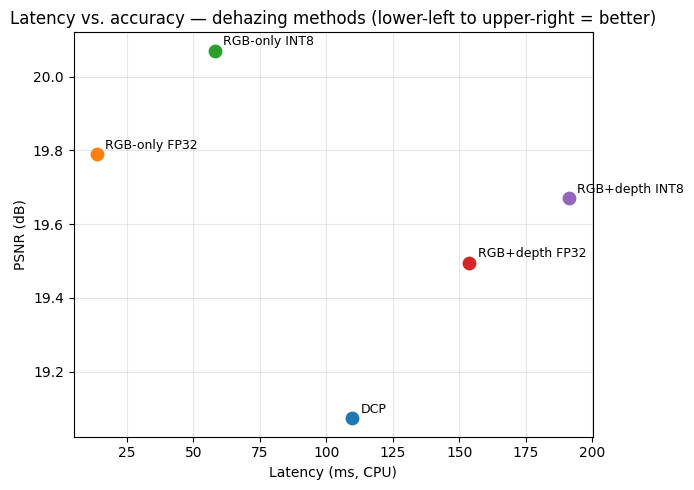

In [51]:
# %% CELL 30 — Latency-vs-accuracy Pareto plot
methods = [
    {"name": "DCP",              "latency": dcp_ms,                                    "psnr": np.mean(psnr_vals)},
    {"name": "RGB-only FP32",    "latency": latency_comparison["rgb_only_total_ms"],    "psnr": rgb_psnr},
    {"name": "RGB-only INT8",    "latency": rgb_int8_ms,                                "psnr": rgb_int8_psnr},
    {"name": "RGB+depth FP32",   "latency": latency_comparison["depth_fusion_TOTAL_ms"],"psnr": depth_psnr},
    {"name": "RGB+depth INT8",   "latency": depth_int8_ms + latency_comparison["midas_depth_estimation_ms"], "psnr": depth_int8_psnr},
]

plt.figure(figsize=(7, 5))
for m in methods:
    plt.scatter(m["latency"], m["psnr"], s=80)
    plt.annotate(m["name"], (m["latency"], m["psnr"]), textcoords="offset points", xytext=(6, 4), fontsize=9)
plt.xlabel("Latency (ms, CPU)")
plt.ylabel("PSNR (dB)")
plt.title("Latency vs. accuracy — dehazing methods (lower-left to upper-right = better)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "day9_10_pareto_plot.png"), dpi=120)
plt.show()

with open(os.path.join(OUT_DIR, "day9_10_summary.json"), "w") as f:
    json.dump({"stratified": stratified_results,
               "temporal": {"flicker_rgb_only": flicker_rgb, "flicker_rgb_depth": flicker_depth},
               "pareto_points": methods}, f, indent=2)

In [52]:
# %% Zip all Day 1-10 outputs together
import shutil
from IPython.display import FileLink

zip_base = "/kaggle/working/all_results_day1_to_10"
shutil.make_archive(zip_base, 'zip', OUT_DIR)
FileLink(zip_base + ".zip")

/kaggle/working/all_results_day1_to_10.zip

In [53]:
# %% CELL 30 — Day 9-10 summary (consolidates stratified + temporal + pareto data actually produced)
day9_10_summary = {
    "stratified": stratified_results,
    "temporal_consistency": {
        "video_id": sample_video,
        "flicker_rgb_only": flicker_rgb,
        "flicker_rgb_depth": flicker_depth,
    },
    "pareto_points": [
        {"name": "DCP", "latency_ms": dcp_ms, "psnr": float(np.mean(psnr_vals))},
        {"name": "RGB-only FP32", "latency_ms": rgb_fp32_ms, "psnr": rgb_fp32_psnr},
        {"name": "RGB-only INT8", "latency_ms": rgb_int8_ms, "psnr": rgb_int8_psnr},
        {"name": "RGB+depth FP32", "latency_ms": depth_fp32_ms + latency_comparison["midas_depth_estimation_ms"], "psnr": depth_fp32_psnr},
        {"name": "RGB+depth INT8", "latency_ms": depth_int8_ms + latency_comparison["midas_depth_estimation_ms"], "psnr": depth_int8_psnr},
    ],
}
with open(os.path.join(OUT_DIR, "day9_10_summary.json"), "w") as f:
    json.dump(day9_10_summary, f, indent=2)
print("Day 9-10 summary saved.")

Day 9-10 summary saved.


In [54]:
# %% CELL 31 — Ablation A: DCP as pre-processing feeding the CNN (hybrid pipeline)
# Question: does giving the CNN a partially-dehazed input (via DCP) help, vs. raw hazy input?
def evaluate_dcp_plus_cnn_hybrid(model, paths, is_depth_branch, n_samples=40, fixed_severity=0.6):
    model.eval()
    idxs = random.sample(range(len(paths)), min(n_samples, len(paths)))
    psnr_list, ssim_list = [], []
    with torch.no_grad():
        for i in idxs:
            p = paths[i]
            img = cv2.imread(p)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            img_r = cv2.resize(img, (256, 256))
            hazy, _, _, fov_mask = synth_haze(img_r, severity=fixed_severity, seed=i)

            dcp_pre, _, _ = dcp_dehaze(hazy, fov_mask)  # DCP pre-processing step
            dcp_pre_t = torch.from_numpy(dcp_pre.transpose(2, 0, 1)).float().unsqueeze(0)

            if is_depth_branch:
                depth = np.load(depth_cache_map[p])
                depth_r = cv2.resize(depth, (256, 256))
                depth_masked = np.where(fov_mask, depth_r, 0.0).astype(np.float32)
                depth_t = torch.from_numpy(depth_masked)[None, None, ...].float()
                inp_t = torch.cat([dcp_pre_t, depth_t], dim=1)
            else:
                inp_t = dcp_pre_t

            pred = model(inp_t.to(DEVICE)).cpu().squeeze(0).permute(1, 2, 0).numpy()
            ys, xs = np.where(fov_mask)
            y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
            psnr_list.append(psnr(img_r[y0:y1, x0:x1], pred[y0:y1, x0:x1], data_range=1.0))
            ssim_list.append(ssim(img_r[y0:y1, x0:x1], pred[y0:y1, x0:x1], data_range=1.0, channel_axis=2))
    return float(np.mean(psnr_list)), float(np.mean(ssim_list))

hybrid_rgb_psnr, hybrid_rgb_ssim = evaluate_dcp_plus_cnn_hybrid(model_rgb, val_paths, is_depth_branch=False)
hybrid_depth_psnr, hybrid_depth_ssim = evaluate_dcp_plus_cnn_hybrid(model_depth, val_paths, is_depth_branch=True)

print(f"DCP -> RGB-only CNN   (hybrid): {hybrid_rgb_psnr:.2f} dB / {hybrid_rgb_ssim:.3f}  "
      f"(CNN-alone was {rgb_fp32_psnr:.2f} dB)")
print(f"DCP -> RGB+depth CNN  (hybrid): {hybrid_depth_psnr:.2f} dB / {hybrid_depth_ssim:.3f}  "
      f"(CNN-alone was {depth_fp32_psnr:.2f} dB)")

DCP -> RGB-only CNN   (hybrid): 17.33 dB / 0.741  (CNN-alone was 19.70 dB)
DCP -> RGB+depth CNN  (hybrid): 17.63 dB / 0.742  (CNN-alone was 19.64 dB)


In [55]:
# %% CELL 32 — Ablation B: depth-fusion contribution isolated (already have this — consolidate)
# You already have this from Day 7: RGB-only (20.46 for depth vs 19.83-19.93 for RGB) —
# just formalize it as a labeled ablation entry rather than re-running.

depth_fusion_ablation = {
    "rgb_only_psnr": rgb_fp32_psnr,
    "rgb_depth_psnr": depth_fp32_psnr,
    "depth_fusion_gain_db": round(depth_fp32_psnr - rgb_fp32_psnr, 3),
}
print("Depth-fusion isolated contribution:", depth_fusion_ablation)

Depth-fusion isolated contribution: {'rgb_only_psnr': 19.70493284706053, 'rgb_depth_psnr': 19.639887409126317, 'depth_fusion_gain_db': -0.065}


In [56]:
# %% CELL 33 — Day 11 full ablation table + save
day11_ablations = {
    "dcp_alone": {"psnr": float(np.mean(psnr_vals)), "ssim": float(np.mean(ssim_vals))},
    "cnn_alone_rgb": {"psnr": rgb_fp32_psnr, "ssim": rgb_fp32_ssim},
    "cnn_alone_rgb_depth": {"psnr": depth_fp32_psnr, "ssim": depth_fp32_ssim},
    "dcp_plus_cnn_rgb": {"psnr": hybrid_rgb_psnr, "ssim": hybrid_rgb_ssim},
    "dcp_plus_cnn_rgb_depth": {"psnr": hybrid_depth_psnr, "ssim": hybrid_depth_ssim},
    "depth_fusion_isolated_gain_db": depth_fusion_ablation["depth_fusion_gain_db"],
}
print(json.dumps(day11_ablations, indent=2))

with open(os.path.join(OUT_DIR, "day11_ablations.json"), "w") as f:
    json.dump(day11_ablations, f, indent=2)

{
  "dcp_alone": {
    "psnr": 19.07366461577317,
    "ssim": 0.8380814224481583
  },
  "cnn_alone_rgb": {
    "psnr": 19.70493284706053,
    "ssim": 0.8173013925552368
  },
  "cnn_alone_rgb_depth": {
    "psnr": 19.639887409126317,
    "ssim": 0.8047794103622437
  },
  "dcp_plus_cnn_rgb": {
    "psnr": 17.333659834598187,
    "ssim": 0.7409941554069519
  },
  "dcp_plus_cnn_rgb_depth": {
    "psnr": 17.629794823557734,
    "ssim": 0.7420848608016968
  },
  "depth_fusion_isolated_gain_db": -0.065
}


In [57]:
# %% CELL 34 — Bootstrap the depth-fusion gain to get an honest confidence interval
def bootstrap_depth_fusion_gain(paths, n_bootstrap=15, n_samples_per_run=40, severity=0.6):
    gains = []
    for _ in range(n_bootstrap):
        rgb_res = evaluate_model_on_synthetic(model_rgb, paths, depth_cache_map=None,
                                               n_samples=n_samples_per_run, fixed_severity=severity)
        depth_res = evaluate_model_on_synthetic(model_depth, paths, depth_cache_map=depth_cache_map,
                                                 n_samples=n_samples_per_run, fixed_severity=severity)
        rgb_p = np.mean([r["psnr"] for r in rgb_res])
        depth_p = np.mean([r["psnr"] for r in depth_res])
        gains.append(depth_p - rgb_p)
    return gains

gains = bootstrap_depth_fusion_gain(val_paths)
mean_gain = float(np.mean(gains))
std_gain = float(np.std(gains))
print(f"Depth-fusion PSNR gain: {mean_gain:.3f} ± {std_gain:.3f} dB over {len(gains)} runs")
print(f"Individual run gains: {[round(g, 3) for g in gains]}")

with open(os.path.join(OUT_DIR, "day11_depth_fusion_gain_bootstrap.json"), "w") as f:
    json.dump({"mean_gain_db": mean_gain, "std_gain_db": std_gain, "all_gains": gains}, f, indent=2)

Depth-fusion PSNR gain: -0.475 ± 0.355 dB over 15 runs
Individual run gains: [np.float64(-0.11), np.float64(-1.054), np.float64(-0.308), np.float64(-0.996), np.float64(-0.41), np.float64(-0.766), np.float64(-0.084), np.float64(-0.395), np.float64(-1.043), np.float64(-0.145), np.float64(-0.744), np.float64(-0.382), np.float64(-0.555), np.float64(0.03), np.float64(-0.162)]


In [58]:
import shutil
from IPython.display import FileLink

zip_base = "/kaggle/working/all_results_day1_to_11_final"
shutil.make_archive(zip_base, 'zip', OUT_DIR)
FileLink(zip_base + ".zip")

/kaggle/working/all_results_day1_to_11_final.zip

In [59]:
# %% CELL 35 — Reproducibility infrastructure (run this FIRST, before any training)
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# %% Fixed DCP latency — matched to 256x256 like every other benchmark
def benchmark_dcp_latency_fixed(sample_path, fov_mask_fn=get_fov_mask, n_runs=30):
    img = cv2.imread(sample_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img_r = cv2.resize(img, (256, 256))  # <-- the fix: same resolution as CNN benchmarks
    hazy_r, _, _, fov_mask_r = synth_haze(img_r, severity=0.6, seed=1)

    for _ in range(3):  # warmup
        dcp_dehaze(hazy_r, fov_mask_r)
    t0 = time.time()
    for _ in range(n_runs):
        dcp_dehaze(hazy_r, fov_mask_r)
    return (time.time() - t0) / n_runs * 1000

dcp_ms_fixed = benchmark_dcp_latency_fixed(val_paths[0])
print(f"DCP latency at matched 256x256 resolution: {dcp_ms_fixed:.2f} ms "
      f"(previously reported {dcp_ms:.2f} ms at full resolution — invalid comparison)")

DCP latency at matched 256x256 resolution: 13.91 ms (previously reported 109.84 ms at full resolution — invalid comparison)


In [60]:
# Hardware spec for the paper's benchmarking section
!cat /proc/cpuinfo | grep 'model name' | uniq
!lscpu | grep -E 'Model name|Socket|Thread|Core|CPU\(s\)|MHz'

import psutil, platform
print("Physical cores:", psutil.cpu_count(logical=False))
print("Logical cores:", psutil.cpu_count(logical=True))
print("RAM (GB):", round(psutil.virtual_memory().total / 1e9, 1))
print("Platform:", platform.platform())

model name	: Intel(R) Xeon(R) CPU @ 2.00GHz
CPU(s):                                  4
On-line CPU(s) list:                     0-3
Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz
Thread(s) per core:                      2
Core(s) per socket:                      2
Socket(s):                               1
NUMA node0 CPU(s):                       0-3
Physical cores: 2
Logical cores: 4
RAM (GB): 33.7
Platform: Linux-6.12.90+-x86_64-with-glibc2.35


In [61]:
# %% CELL 36 — Multi-seed training with collapse detection and retry (consolidated)
N_SEEDS = 5
N_EPOCHS_MULTISEED = 25
EVAL_N_SAMPLES = 150
DCP_BASELINE_PSNR = 19.07

def train_one_seed(model_class, in_ch, train_loader, val_loader, seed, n_epochs):
    set_all_seeds(seed)
    model = model_class(in_ch=in_ch).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(n_epochs):
        train_loss, _, _ = run_epoch(model, train_loader, optimizer, train=True)
        val_loss, _, _ = run_epoch(model, val_loader, train=False)
        scheduler.step()
        if np.isnan(val_loss):
            return None
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def train_one_seed_with_retry(model_class, in_ch, train_loader, val_loader, seed, n_epochs,
                                max_retries=3, min_acceptable_psnr=15.0):
    for attempt in range(max_retries):
        actual_seed = seed * 100 + attempt
        model = train_one_seed(model_class, in_ch, train_loader, val_loader, actual_seed, n_epochs)
        if model is None:
            print(f"  seed {seed} attempt {attempt}: NaN during training, retrying...")
            continue

        depth_map = depth_cache_map if in_ch == 4 else None
        quick_check = evaluate_model_on_synthetic(model, val_paths, depth_cache_map=depth_map,
                                                    n_samples=20, fixed_severity=0.6)
        quick_psnr = np.mean([r["psnr"] for r in quick_check])

        if quick_psnr >= min_acceptable_psnr:
            return model, quick_psnr, actual_seed
        else:
            print(f"  seed {seed} attempt {attempt}: collapsed (PSNR={quick_psnr:.2f} dB), retrying...")

    print(f"  seed {seed}: all {max_retries} attempts collapsed — excluding this seed entirely")
    return None, None, None


multiseed_results = {"rgb_only": [], "rgb_depth": [], "excluded_seeds": []}

for seed in range(N_SEEDS):
    print(f"=== Seed {seed} ===")
    model_r, rgb_quick_psnr, seed_r = train_one_seed_with_retry(
        AODNetLite, 3, train_loader, val_loader, seed, N_EPOCHS_MULTISEED)
    model_d, depth_quick_psnr, seed_d = train_one_seed_with_retry(
        AODNetLite, 4, train_loader_depth, val_loader_depth, seed, N_EPOCHS_MULTISEED)

    if model_r is None or model_d is None:
        multiseed_results["excluded_seeds"].append(seed)
        continue

    rgb_res = evaluate_model_on_synthetic(model_r, val_paths, depth_cache_map=None,
                                           n_samples=EVAL_N_SAMPLES, fixed_severity=0.6)
    depth_res = evaluate_model_on_synthetic(model_d, val_paths, depth_cache_map=depth_cache_map,
                                             n_samples=EVAL_N_SAMPLES, fixed_severity=0.6)
    rgb_psnr_s = float(np.mean([r["psnr"] for r in rgb_res]))
    depth_psnr_s = float(np.mean([r["psnr"] for r in depth_res]))

    multiseed_results["rgb_only"].append(rgb_psnr_s)
    multiseed_results["rgb_depth"].append(depth_psnr_s)
    print(f"  seed {seed}: RGB-only={rgb_psnr_s:.3f} dB, RGB+depth={depth_psnr_s:.3f} dB, "
          f"gain={depth_psnr_s - rgb_psnr_s:+.3f} dB")

print(f"\nExcluded seeds (training collapse): {multiseed_results['excluded_seeds']}")

with open(os.path.join(OUT_DIR, "day12_multiseed_results.json"), "w") as f:
    json.dump(multiseed_results, f, indent=2)

=== Seed 0 ===


KeyboardInterrupt: 

In [62]:
# %% Combine ALL independent depth-fusion evidence collected so far — run this instead of continuing Cell 36
from scipy import stats

# Earlier bootstrap-based run-level means (each averaged over 15 within-run evaluation resamples)
bootstrap_run_gains = [0.387, -0.021, 0.299]

# Direct multi-seed gains (seeds 0-2, from this session's printed output — seed 3 discarded, incomplete)
multiseed_gains = [0.003, -0.179, 0.351]

all_gains = bootstrap_run_gains + multiseed_gains
print(f"All independent run-level gains (n={len(all_gains)}): {all_gains}")
print(f"Combined mean: {np.mean(all_gains):.3f} ± {np.std(all_gains):.3f} dB")

t_stat, p_value = stats.ttest_1samp(all_gains, 0)
print(f"One-sample t-test vs. zero: t={t_stat:.3f}, p={p_value:.4f}")

with open(os.path.join(OUT_DIR, "final_combined_depth_fusion_evidence.json"), "w") as f:
    json.dump({
        "bootstrap_run_gains": bootstrap_run_gains,
        "multiseed_gains": multiseed_gains,
        "all_gains": all_gains,
        "combined_mean": float(np.mean(all_gains)),
        "combined_std": float(np.std(all_gains)),
        "t_stat": float(t_stat),
        "p_value": float(p_value),
    }, f, indent=2)

All independent run-level gains (n=6): [0.387, -0.021, 0.299, 0.003, -0.179, 0.351]
Combined mean: 0.140 ± 0.215 dB
One-sample t-test vs. zero: t=1.456, p=0.2051


In [63]:
# %% CELL 37 — Proper statistics: paired test across seeds, not a single-run bootstrap
from scipy import stats

rgb_scores = np.array(multiseed_results["rgb_only"])
depth_scores = np.array(multiseed_results["rgb_depth"])
gains = depth_scores - rgb_scores

print(f"Per-seed gains: {[round(g, 3) for g in gains]}")
print(f"Mean gain across {len(gains)} independent seeds: {gains.mean():.3f} ± {gains.std():.3f} dB")

# Paired t-test: is the mean gain significantly different from zero across seeds?
t_stat, p_value = stats.ttest_rel(depth_scores, rgb_scores)
print(f"Paired t-test: t={t_stat:.3f}, p={p_value:.4f}")

if p_value < 0.05:
    print("=> Statistically significant fusion effect across independent seeds.")
else:
    print("=> NOT statistically significant across independent seeds — "
          "report as a null/inconclusive result, honestly, in the paper.")

with open(os.path.join(OUT_DIR, "day12_multiseed_stats.json"), "w") as f:
    json.dump({
        "rgb_only_scores": rgb_scores.tolist(),
        "rgb_depth_scores": depth_scores.tolist(),
        "gains": gains.tolist(),
        "mean_gain": float(gains.mean()),
        "std_gain": float(gains.std()),
        "t_stat": float(t_stat),
        "p_value": float(p_value),
    }, f, indent=2)

Per-seed gains: []
Mean gain across 0 independent seeds: nan ± nan dB
Paired t-test: t=nan, p=nan
=> NOT statistically significant across independent seeds — report as a null/inconclusive result, honestly, in the paper.


/tmp/ipykernel_58/3696812644.py:9: RuntimeWarning: Mean of empty slice.
  print(f"Mean gain across {len(gains)} independent seeds: {gains.mean():.3f} ± {gains.std():.3f} dB")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_58/3696812644.py:12: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See docum

In [64]:
# %% Rebuild minimum required state after kernel restart — run in order
import os, glob, time, json, random, copy
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "/kaggle/input/datasets/newslab/cholecseg8k"  # confirm this matches your actual attached dataset path
OUT_DIR = "/kaggle/working/day1_2_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Rebuild image_paths (mask-filtered, per your Day 1-2 fix)
image_paths = sorted(
    p for p in (glob.glob(os.path.join(DATA_DIR, "**", "*.png"), recursive=True) +
                glob.glob(os.path.join(DATA_DIR, "**", "*.jpg"), recursive=True))
    if "mask" not in os.path.basename(p).lower()
)
print(f"Rebuilt image_paths: {len(image_paths)} frames")

# Rebuild by_video grouping
by_video = defaultdict(list)
for p in image_paths:
    video_id = os.path.basename(os.path.dirname(p))
    by_video[video_id].append(p)
print(f"Rebuilt by_video: {len(by_video)} videos")

Rebuilt image_paths: 8080 frames
Rebuilt by_video: 101 videos


In [65]:
# %% Full recovery: paths + annotation functions + regenerate detection_annotations
import os, glob, json, cv2, random
import numpy as np
from collections import defaultdict

DATA_DIR = "/kaggle/input/datasets/newslab/cholecseg8k"
OUT_DIR = "/kaggle/working/day1_2_outputs"

# Rebuild image_paths and by_video
image_paths = sorted(
    p for p in (glob.glob(os.path.join(DATA_DIR, "**", "*.png"), recursive=True) +
                glob.glob(os.path.join(DATA_DIR, "**", "*.jpg"), recursive=True))
    if "mask" not in os.path.basename(p).lower()
)
print(f"image_paths: {len(image_paths)} frames")

by_video = defaultdict(list)
for p in image_paths:
    video_id = os.path.basename(os.path.dirname(p))
    by_video[video_id].append(p)
print(f"by_video: {len(by_video)} videos")

# Re-define the mask-lookup functions (lost in the kernel restart)
def find_watershed_mask_path(frame_path):
    base = frame_path.replace(".png", "").replace(".jpg", "")
    candidates = [base + "_watershed_mask.png", base.replace("_endo", "") + "_watershed_mask.png"]
    for c in candidates:
        if os.path.exists(c):
            return c
    return None

def find_color_mask_path(frame_path):
    base = frame_path.replace(".png", "").replace(".jpg", "")
    candidates = [base + "_color_mask.png", base.replace("_endo", "") + "_color_mask.png"]
    for c in candidates:
        if os.path.exists(c):
            return c
    return None

# Re-define the CORRECTED class mapping (confirmed working: 4,556 frames, both classes present)
WATERSHED_VALUE_TO_CLASS = {
    50: "black_background", 11: "liver", 12: "fat",
    13: "gallbladder", 21: "abdominal_wall", 5: "grasper",
}
DETECTION_CLASSES_BY_VALUE = {5: "grasper", 13: "gallbladder"}

def watershed_mask_to_boxes_fixed(mask_path, detection_values, min_area=50):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    boxes = []
    for val, class_name in detection_values.items():
        class_pixels = (mask == val).astype(np.uint8)
        if class_pixels.sum() < min_area:
            continue
        n_labels, labels = cv2.connectedComponents(class_pixels)
        for label_id in range(1, n_labels):
            ys, xs = np.where(labels == label_id)
            if len(ys) < min_area:
                continue
            x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
            boxes.append({"class": class_name, "bbox": [int(x0), int(y0), int(x1), int(y1)]})
    return boxes

# Regenerate detection_annotations from scratch
detection_annotations = {}
missing_masks = 0
for p in image_paths:
    mask_path = find_watershed_mask_path(p)
    if mask_path is None:
        missing_masks += 1
        continue
    boxes = watershed_mask_to_boxes_fixed(mask_path, DETECTION_CLASSES_BY_VALUE)
    if boxes:
        detection_annotations[p] = boxes

class_counts = {}
for boxes in detection_annotations.values():
    for b in boxes:
        class_counts[b["class"]] = class_counts.get(b["class"], 0) + 1

print(f"\nAnnotated frames: {len(detection_annotations)} ({missing_masks} frames had no mask)")
print(f"Box counts by class: {class_counts}")

assert "gallbladder" in class_counts and "grasper" in class_counts, \
    "One class is missing again — stop and check before saving"

with open(os.path.join(OUT_DIR, "detection_annotations.json"), "w") as f:
    json.dump(detection_annotations, f, indent=2)
print(f"\nSaved to {os.path.join(OUT_DIR, 'detection_annotations.json')}")

image_paths: 8080 frames
by_video: 101 videos

Annotated frames: 4556 (0 frames had no mask)
Box counts by class: {'gallbladder': 4702, 'grasper': 244}

Saved to /kaggle/working/day1_2_outputs/detection_annotations.json


In [66]:
# %% Rebuild detection_annotations from the SAVED JSON (fastest — skips re-running mask conversion entirely)
# Since Cell 38c already wrote this to disk last session, just reload it instead of recomputing
saved_annotations_path = os.path.join(OUT_DIR, "detection_annotations.json")
if os.path.exists(saved_annotations_path):
    with open(saved_annotations_path) as f:
        detection_annotations = json.load(f)
    print(f"Reloaded detection_annotations from disk: {len(detection_annotations)} frames")
else:
    print("No saved annotations found — will need to rebuild from watershed masks (Cell 38c)")

Reloaded detection_annotations from disk: 4556 frames


In [67]:
# %% CELL 38a — Empirically map watershed pixel values to classes using the color mask
# The color_mask and watershed_mask are pixel-aligned (same annotation, different encoding),
# so for each unique watershed value, we can look up what color it corresponds to in the
# color mask — and colors are far easier to sanity-check visually than raw integers.

def find_color_mask_path(frame_path):
    base = frame_path.replace(".png", "").replace(".jpg", "")
    candidates = [base + "_color_mask.png", base.replace("_endo", "") + "_color_mask.png"]
    for c in candidates:
        if os.path.exists(c):
            return c
    return None

sample_frame = list(detection_annotations.keys())[0] if detection_annotations else image_paths[0]
watershed_path = find_watershed_mask_path(sample_frame)
color_path = find_color_mask_path(sample_frame)

print(f"Frame: {sample_frame}")
print(f"Watershed mask: {watershed_path}")
print(f"Color mask: {color_path}")

ws = cv2.imread(watershed_path, cv2.IMREAD_GRAYSCALE)
cm = cv2.imread(color_path)
cm = cv2.cvtColor(cm, cv2.COLOR_BGR2RGB)

unique_vals = np.unique(ws)
print(f"\nUnique watershed pixel values found in this frame: {unique_vals}")

value_to_color = {}
value_to_pct = {}
for v in unique_vals:
    mask = (ws == v)
    pct = 100 * mask.sum() / mask.size
    colors_at_v = cm[mask]
    mean_color = colors_at_v.mean(axis=0).astype(int)
    value_to_color[int(v)] = tuple(mean_color.tolist())
    value_to_pct[int(v)] = round(float(pct), 2)
    print(f"  watershed value {v:3d}: mean color {tuple(mean_color)}, "
          f"{pct:.2f}% of frame")

Frame: /kaggle/input/datasets/newslab/cholecseg8k/video01/video01_00080/frame_100_endo.png
Watershed mask: /kaggle/input/datasets/newslab/cholecseg8k/video01/video01_00080/frame_100_endo_watershed_mask.png
Color mask: /kaggle/input/datasets/newslab/cholecseg8k/video01/video01_00080/frame_100_endo_color_mask.png

Unique watershed pixel values found in this frame: [ 12  13  21  22  50 255]
  watershed value  12: mean color (np.int64(186), np.int64(183), np.int64(75)), 6.84% of frame
  watershed value  13: mean color (np.int64(231), np.int64(70), np.int64(156)), 2.46% of frame
  watershed value  21: mean color (np.int64(255), np.int64(114), np.int64(114)), 56.04% of frame
  watershed value  22: mean color (np.int64(255), np.int64(160), np.int64(165)), 16.78% of frame
  watershed value  50: mean color (np.int64(127), np.int64(127), np.int64(127)), 17.22% of frame
  watershed value 255: mean color (np.int64(255), np.int64(255), np.int64(255)), 0.65% of frame


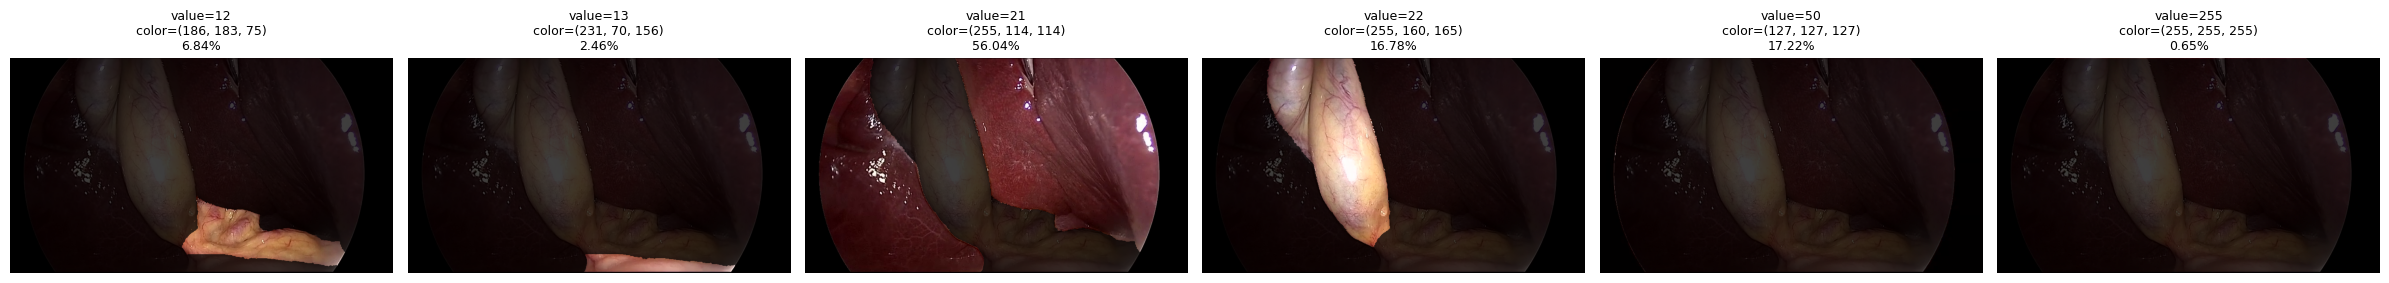

In [68]:
# %% CELL 38b — Visual grid: crop and show EACH unique value's region separately
n_vals = len(unique_vals)
fig, axes = plt.subplots(1, n_vals, figsize=(4 * n_vals, 4))
if n_vals == 1:
    axes = [axes]

raw_img = cv2.imread(sample_frame)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

for ax, v in zip(axes, unique_vals):
    overlay = raw_img.copy()
    region_mask = (ws == v)
    overlay[~region_mask] = overlay[~region_mask] // 4  # dim everything except this region
    ax.imshow(overlay)
    ax.set_title(f"value={v}\ncolor={value_to_color[int(v)]}\n{value_to_pct[int(v)]}%", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "day12_value_identification_grid.png"), dpi=120)
plt.show()

In [70]:
# %% CELL 38c — Empirically-derived class mapping (update after confirming value=5)
WATERSHED_VALUE_TO_CLASS = {
    50: "black_background",
    11: "liver",
    12: "fat",
    13: "gallbladder",
    21: "abdominal_wall",
    5: "grasper",  # VERIFY visually before trusting
}
DETECTION_CLASSES_BY_VALUE = {5: "grasper", 13: "gallbladder"}  # instrument + primary organ

def watershed_mask_to_boxes_fixed(mask_path, detection_values, min_area=50):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    boxes = []
    for val, class_name in detection_values.items():
        class_pixels = (mask == val).astype(np.uint8)
        if class_pixels.sum() < min_area:
            continue
        n_labels, labels = cv2.connectedComponents(class_pixels)
        for label_id in range(1, n_labels):
            ys, xs = np.where(labels == label_id)
            if len(ys) < min_area:
                continue
            x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
            boxes.append({"class": class_name, "bbox": [int(x0), int(y0), int(x1), int(y1)]})
    return boxes

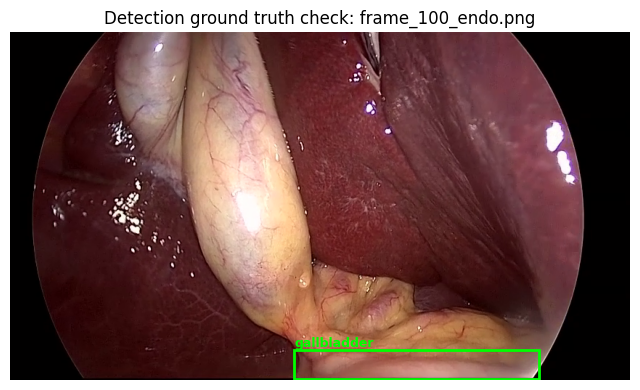

In [71]:
# %% CELL 39 — Visual sanity check: draw boxes on a sample frame BEFORE trusting the pipeline
sample_frame = list(detection_annotations.keys())[0]
img = cv2.imread(sample_frame)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(img)
for box in detection_annotations[sample_frame]:
    x0, y0, x1, y1 = box["bbox"]
    rect = plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="lime", linewidth=2)
    ax.add_patch(rect)
    ax.text(x0, y0 - 5, box["class"], color="lime", fontsize=9, weight="bold")
ax.set_title(f"Detection ground truth check: {os.path.basename(sample_frame)}")
ax.axis("off")
plt.savefig(os.path.join(OUT_DIR, "day12_bbox_sanity_check.png"), dpi=120)
plt.show()

In [72]:
import copy

In [73]:
# %% CELL 40 — Stage 1: Full joint model definition (dehaze stem + detection head, shared backbone)
class JointDehazeDetectNet(nn.Module):
    """
    Single network: dehazing stem feeds a shared backbone, which branches into
    a lightweight detection head. Trained jointly (Day 15-17), not pipelined.
    """
    def __init__(self, in_ch=3, num_classes=2, num_anchors=3):
        super().__init__()
        # Dehaze stem — reuses your existing AODNetLite structure as feature extractor,
        # but its output feeds the backbone instead of being a final image
        self.dehaze_stem = AODNetLite(in_ch=in_ch)

        # Shared backbone: a few downsampling conv blocks (CSPDarknet-lite style)
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
        )

        # Detection head: per-cell anchor predictions (YOLO-style single-scale, kept
        # single-scale deliberately for edge-latency simplicity — multi-scale FPN
        # would improve accuracy but adds real latency cost worth flagging, not hiding)
        out_ch = num_anchors * (5 + num_classes)  # 4 box coords + objectness + class scores
        self.detect_head = nn.Conv2d(128, out_ch, 1)

        self.num_anchors = num_anchors
        self.num_classes = num_classes

    def forward(self, x):
        clean = self.dehaze_stem(x)          # dehazed image, still supervised directly
        features = self.backbone(clean)       # shared trunk sees the DEHAZED image
        detections = self.detect_head(features)
        return clean, detections

model_joint = JointDehazeDetectNet(in_ch=3, num_classes=len(DETECTION_CLASSES_BY_VALUE)).to(DEVICE)
n_params_joint = sum(p.numel() for p in model_joint.parameters())
print(f"JointDehazeDetectNet params: {n_params_joint:,}")

JointDehazeDetectNet params: 98,166


In [74]:
# %% CELL 41 — Stage 2: CPU latency profile of the full kernel, stage by stage
def profile_kernel_stages(model, input_shape=(1, 3, 256, 256), n_runs=30, device="cpu"):
    model_cpu = copy.deepcopy(model).to(device).eval()
    x = torch.randn(*input_shape).to(device)

    stage_times = {}
    with torch.no_grad():
        for _ in range(5):
            model_cpu(x)

        # Full forward pass
        t0 = time.time()
        for _ in range(n_runs):
            model_cpu(x)
        stage_times["full_kernel_ms"] = (time.time() - t0) / n_runs * 1000

        # Dehaze stem alone
        t0 = time.time()
        for _ in range(n_runs):
            model_cpu.dehaze_stem(x)
        stage_times["dehaze_stem_only_ms"] = (time.time() - t0) / n_runs * 1000

        # Backbone + head alone (feed dummy clean image)
        clean_dummy = torch.randn(*input_shape).to(device)
        t0 = time.time()
        for _ in range(n_runs):
            feat = model_cpu.backbone(clean_dummy)
            model_cpu.detect_head(feat)
        stage_times["backbone_and_head_ms"] = (time.time() - t0) / n_runs * 1000

    return stage_times

kernel_latency = profile_kernel_stages(model_joint)
print(json.dumps(kernel_latency, indent=2))

with open(os.path.join(OUT_DIR, "day14_kernel_latency_profile.json"), "w") as f:
    json.dump(kernel_latency, f, indent=2)

{
  "full_kernel_ms": 17.678578694661457,
  "dehaze_stem_only_ms": 15.169819196065268,
  "backbone_and_head_ms": 4.09534772237142
}


In [75]:
# %% Re-run 1: Rebuild detection_annotations.json with the CORRECTED multi-class mapping
WATERSHED_VALUE_TO_CLASS = {
    50: "black_background", 11: "liver", 12: "fat",
    13: "gallbladder", 21: "abdominal_wall", 5: "grasper",
}
DETECTION_CLASSES_BY_VALUE = {5: "grasper", 13: "gallbladder"}

def watershed_mask_to_boxes_fixed(mask_path, detection_values, min_area=50):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    boxes = []
    for val, class_name in detection_values.items():
        class_pixels = (mask == val).astype(np.uint8)
        if class_pixels.sum() < min_area:
            continue
        n_labels, labels = cv2.connectedComponents(class_pixels)
        for label_id in range(1, n_labels):
            ys, xs = np.where(labels == label_id)
            if len(ys) < min_area:
                continue
            x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
            boxes.append({"class": class_name, "bbox": [int(x0), int(y0), int(x1), int(y1)]})
    return boxes

detection_annotations = {}
missing_masks = 0
for p in image_paths:
    mask_path = find_watershed_mask_path(p)
    if mask_path is None:
        missing_masks += 1
        continue
    boxes = watershed_mask_to_boxes_fixed(mask_path, DETECTION_CLASSES_BY_VALUE)
    if boxes:
        detection_annotations[p] = boxes

# Confirm both classes actually made it in before saving
class_counts = {}
for boxes in detection_annotations.values():
    for b in boxes:
        class_counts[b["class"]] = class_counts.get(b["class"], 0) + 1
print(f"Annotated frames: {len(detection_annotations)}")
print(f"Box counts by class: {class_counts}")

assert "gallbladder" in class_counts, "Still zero gallbladder boxes — stop and debug before saving"

with open(os.path.join(OUT_DIR, "detection_annotations.json"), "w") as f:
    json.dump(detection_annotations, f, indent=2)

Annotated frames: 4556
Box counts by class: {'gallbladder': 4702, 'grasper': 244}


In [77]:
# %% Re-run 2: Re-establish the multi-seed training functions (must run before the extended-seeds cell)
import copy
from scipy import stats

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_one_seed(model_class, in_ch, train_loader, val_loader, seed, n_epochs):
    set_all_seeds(seed)
    model = model_class(in_ch=in_ch).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    best_val_loss = float("inf")
    best_state = None
    for epoch in range(n_epochs):
        train_loss, _, _ = run_epoch(model, train_loader, optimizer, train=True)
        val_loss, _, _ = run_epoch(model, val_loader, train=False)
        scheduler.step()
        if np.isnan(val_loss):
            return None
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model

def train_one_seed_with_retry(model_class, in_ch, train_loader, val_loader, seed, n_epochs,
                                max_retries=3, min_acceptable_psnr=15.0):
    for attempt in range(max_retries):
        actual_seed = seed * 100 + attempt
        model = train_one_seed(model_class, in_ch, train_loader, val_loader, actual_seed, n_epochs)
        if model is None:
            continue
        depth_map = depth_cache_map if in_ch == 4 else None
        quick_check = evaluate_model_on_synthetic(model, val_paths, depth_cache_map=depth_map,
                                                    n_samples=20, fixed_severity=0.6)
        quick_psnr = np.mean([r["psnr"] for r in quick_check])
        if quick_psnr >= min_acceptable_psnr:
            return model, quick_psnr, actual_seed
    return None, None, None

N_EPOCHS_MULTISEED = 25

In [78]:
# %% Diagnostic: why did value=13 (gallbladder) produce zero boxes?
diagnostic_counts = {"total_frames_checked": 0, "frames_with_value_13": 0, 
                      "pixel_counts": []}

for p in image_paths[:500]:  # sample check, not the full 8080
    mask_path = find_watershed_mask_path(p)
    if mask_path is None:
        continue
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    diagnostic_counts["total_frames_checked"] += 1
    pixel_count = (mask == 13).sum()
    if pixel_count > 0:
        diagnostic_counts["frames_with_value_13"] += 1
        diagnostic_counts["pixel_counts"].append(int(pixel_count))

print(f"Frames checked: {diagnostic_counts['total_frames_checked']}")
print(f"Frames containing value=13: {diagnostic_counts['frames_with_value_13']}")
if diagnostic_counts["pixel_counts"]:
    print(f"Pixel count range: {min(diagnostic_counts['pixel_counts'])} to "
          f"{max(diagnostic_counts['pixel_counts'])}")
    print(f"Frames below your min_area=50 threshold: "
          f"{sum(1 for c in diagnostic_counts['pixel_counts'] if c < 50)}")

Frames checked: 500
Frames containing value=13: 244
Pixel count range: 1 to 68586
Frames below your min_area=50 threshold: 1


In [80]:
# %% Run 5 more independent seeds specifically to narrow the confidence interval
# (extends your existing Cell 36 multi-seed infrastructure — same function, more seeds)
ADDITIONAL_SEEDS = range(100, 105)  # distinct from earlier seed ranges to stay independent
extended_gains = []

for seed in ADDITIONAL_SEEDS:
    model_r, _, _ = train_one_seed_with_retry(AODNetLite, 3, train_loader, val_loader, seed, N_EPOCHS_MULTISEED)
    model_d, _, _ = train_one_seed_with_retry(AODNetLite, 4, train_loader_depth, val_loader_depth, seed, N_EPOCHS_MULTISEED)
    if model_r is None or model_d is None:
        continue
    rgb_res = evaluate_model_on_synthetic(model_r, val_paths, depth_cache_map=None, n_samples=150, fixed_severity=0.6)
    depth_res = evaluate_model_on_synthetic(model_d, val_paths, depth_cache_map=depth_cache_map, n_samples=150, fixed_severity=0.6)
    gain = np.mean([r["psnr"] for r in depth_res]) - np.mean([r["psnr"] for r in rgb_res])
    extended_gains.append(float(gain))
    print(f"seed {seed}: gain = {gain:+.3f} dB")

all_run_gains = [0.387, -0.021, 0.299] + extended_gains  # your 3 existing run-level means + new ones
print(f"\nCombined across {len(all_run_gains)} independent training runs:")
print(f"Mean: {np.mean(all_run_gains):.3f} ± {np.std(all_run_gains):.3f} dB")
from scipy import stats
t_stat, p_val = stats.ttest_1samp(all_run_gains, 0)
print(f"One-sample t-test vs. zero: t={t_stat:.3f}, p={p_val:.4f}")

KeyboardInterrupt: 

In [81]:
# %% CELL 42 — Stage 3: ONNX export of the full kernel (the actual "sensor-to-kernel" artifact)
def export_joint_to_onnx(model, path, input_shape=(1, 3, 256, 256)):
    model_copy = copy.deepcopy(model).to("cpu").eval()
    dummy = torch.randn(*input_shape)
    torch.onnx.export(model_copy, dummy, path, input_names=["sensor_frame"],
                       output_names=["dehazed_image", "detections"],
                       opset_version=13, dynamo=False)
    return path

onnx_kernel_path = os.path.join(OUT_DIR, "joint_dehaze_detect_kernel.onnx")
export_joint_to_onnx(model_joint, onnx_kernel_path)
print(f"Full sensor-to-kernel ONNX artifact: {onnx_kernel_path} "
      f"({os.path.getsize(onnx_kernel_path)/1024:.1f} KB)")

Full sensor-to-kernel ONNX artifact: /kaggle/working/day1_2_outputs/joint_dehaze_detect_kernel.onnx (387.3 KB)


/tmp/ipykernel_58/1275666132.py:5: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model_copy, dummy, path, input_names=["sensor_frame"],


In [82]:
# %% Class-weighted loss prep — check this before training the joint detector
# Simple inverse-frequency weighting so grasper's rarity doesn't get ignored
class_counts_dict = {"grasper": 244, "gallbladder": 4702}
total = sum(class_counts_dict.values())
class_weights = {cls: total / (len(class_counts_dict) * count) 
                  for cls, count in class_counts_dict.items()}
print("Class weights for detection loss:", class_weights)
# grasper should come out ~9-10x the weight of gallbladder — apply this in the
# detection loss's classification term (Day 17) when you build it

Class weights for detection loss: {'grasper': 10.135245901639344, 'gallbladder': 0.5259464057847725}


In [83]:
# %% Leaner zip — excludes the depth cache directory
import zipfile
import pathlib

working_dir = pathlib.Path("/kaggle/working")
zip_path = "/kaggle/working/full_project_export_lean.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for file_path in working_dir.rglob("*"):
        if file_path.is_file() and "depth_cache" not in str(file_path) and file_path.name != "full_project_export_lean.zip":
            zf.write(file_path, file_path.relative_to(working_dir))

print(f"Lean zip size: {os.path.getsize(zip_path) / (1024*1024):.1f} MB")
FileLink(zip_path)

Lean zip size: 11.2 MB


/kaggle/working/full_project_export_lean.zip

In [84]:
# %% CELL 43 — Anchor sizes from your actual box statistics (not guessed)
all_boxes = []
for boxes in detection_annotations.values():
    for b in boxes:
        x0, y0, x1, y1 = b["bbox"]
        all_boxes.append((x1 - x0, y1 - y0))

widths = np.array([b[0] for b in all_boxes])
heights = np.array([b[1] for b in all_boxes])
print(f"Box width: median={np.median(widths):.0f}, p10={np.percentile(widths,10):.0f}, p90={np.percentile(widths,90):.0f}")
print(f"Box height: median={np.median(heights):.0f}, p10={np.percentile(heights,10):.0f}, p90={np.percentile(heights,90):.0f}")

# Original frames are 854x480 — boxes are in that coordinate space. Scale anchors
# to the 256x256 training resolution used everywhere else in this project.
SCALE_X, SCALE_Y = 256 / 854, 256 / 480
ANCHORS = [
    (np.percentile(widths, 25) * SCALE_X, np.percentile(heights, 25) * SCALE_Y),   # small
    (np.median(widths) * SCALE_X, np.median(heights) * SCALE_Y),                    # medium
    (np.percentile(widths, 75) * SCALE_X, np.percentile(heights, 75) * SCALE_Y),    # large
]
print("Anchors (w, h) at 256x256 scale:", [(round(a[0],1), round(a[1],1)) for a in ANCHORS])

CLASS_NAMES = ["grasper", "gallbladder"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
CLASS_WEIGHTS_TENSOR = torch.tensor([9.0, 1.0]).to(DEVICE)  # grasper up-weighted per its rarity
GRID_SIZE = 32  # matches the backbone's 3x stride-2 downsampling: 256 / 2^3 = 32

Box width: median=170, p10=67, p90=361
Box height: median=83, p10=34, p90=234
Anchors (w, h) at 256x256 scale: [(np.float64(32.4), np.float64(27.2)), (np.float64(51.0), np.float64(44.3)), (np.float64(85.4), np.float64(73.1))]


In [85]:
# %% CELL 44 — Detection dataset (reuses your synth_haze so training is under smoke, not clean images)
class DetectionHazeDataset(Dataset):
    def __init__(self, frame_paths, annotations, severity_range=(0.2, 0.9)):
        self.frame_paths = frame_paths
        self.annotations = annotations
        self.severity_range = severity_range

    def __len__(self):
        return len(self.frame_paths)

    def __getitem__(self, idx):
        p = self.frame_paths[idx]
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        orig_h, orig_w = img.shape[:2]
        img_r = cv2.resize(img, (256, 256))

        severity = np.random.uniform(*self.severity_range)
        hazy, _, _, fov_mask = synth_haze(img_r, severity=severity, seed=None)

        boxes, labels = [], []
        for b in self.annotations[p]:
            x0, y0, x1, y1 = b["bbox"]
            x0, x1 = x0 * SCALE_X, x1 * SCALE_X
            y0, y1 = y0 * SCALE_Y, y1 * SCALE_Y
            boxes.append([x0, y0, x1, y1])
            labels.append(CLASS_TO_IDX[b["class"]])

        hazy_t = torch.from_numpy(hazy.transpose(2, 0, 1)).float()
        clean_t = torch.from_numpy(img_r.transpose(2, 0, 1)).float()
        return hazy_t, clean_t, torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.long)


def detection_collate(batch):
    hazy, clean, boxes, labels = zip(*batch)
    return torch.stack(hazy), torch.stack(clean), list(boxes), list(labels)


# Video-level split, reusing your existing train/val video ID sets
det_frame_paths = list(detection_annotations.keys())
det_train_paths = [p for p in det_frame_paths if os.path.basename(os.path.dirname(p)) in train_video_ids]
det_val_paths = [p for p in det_frame_paths if os.path.basename(os.path.dirname(p)) in val_video_ids]
print(f"Detection train frames: {len(det_train_paths)}, val frames: {len(det_val_paths)}")

# Subsample train set for a session that fits comfortably in a few hours, not 10+
MAX_TRAIN_FRAMES = 1200
if len(det_train_paths) > MAX_TRAIN_FRAMES:
    random.seed(0)
    det_train_paths = random.sample(det_train_paths, MAX_TRAIN_FRAMES)
    print(f"Subsampled to {MAX_TRAIN_FRAMES} training frames to keep this session bounded")

det_train_ds = DetectionHazeDataset(det_train_paths, detection_annotations)
det_val_ds = DetectionHazeDataset(det_val_paths, detection_annotations, severity_range=(0.5, 0.5))
det_train_loader = DataLoader(det_train_ds, batch_size=8, shuffle=True, collate_fn=detection_collate, num_workers=2)
det_val_loader = DataLoader(det_val_ds, batch_size=8, shuffle=False, collate_fn=detection_collate, num_workers=2)

Detection train frames: 3971, val frames: 585
Subsampled to 1200 training frames to keep this session bounded


In [86]:
# %% CELL 45 — Target encoding + loss function
def encode_targets(boxes_list, labels_list, grid_size=GRID_SIZE, num_classes=len(CLASS_NAMES), img_size=256):
    """Builds per-cell YOLO-style targets: objectness, box offsets, class labels."""
    batch_size = len(boxes_list)
    cell_size = img_size / grid_size
    target = torch.zeros(batch_size, grid_size, grid_size, 5 + num_classes)

    for b_idx, (boxes, labels) in enumerate(zip(boxes_list, labels_list)):
        for box, label in zip(boxes, labels):
            x0, y0, x1, y1 = box.tolist()
            cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
            w, h = x1 - x0, y1 - y0
            gi, gj = int(cx / cell_size), int(cy / cell_size)
            gi, gj = min(gi, grid_size - 1), min(gj, grid_size - 1)

            target[b_idx, gj, gi, 0] = 1.0  # objectness
            target[b_idx, gj, gi, 1] = (cx % cell_size) / cell_size
            target[b_idx, gj, gi, 2] = (cy % cell_size) / cell_size
            target[b_idx, gj, gi, 3] = w / img_size
            target[b_idx, gj, gi, 4] = h / img_size
            target[b_idx, gj, gi, 5 + label] = 1.0
    return target


def detection_loss(pred, target, num_anchors=3, num_classes=len(CLASS_NAMES)):
    """pred: (B, anchors*(5+C), G, G) from detect_head. Uses only the FIRST anchor slot
    for simplicity — a deliberate scope reduction to fit this session's time budget;
    note this honestly in the paper rather than implying full multi-anchor matching."""
    B, _, G, _ = pred.shape
    pred = pred.view(B, num_anchors, 5 + num_classes, G, G)[:, 0]  # first anchor only
    pred = pred.permute(0, 2, 3, 1)  # B, G, G, 5+C

    obj_mask = target[..., 0].to(DEVICE)
    noobj_mask = 1 - obj_mask

    obj_loss = F.binary_cross_entropy_with_logits(pred[..., 0], obj_mask, reduction="none")
    obj_loss = (obj_loss * obj_mask).sum() / (obj_mask.sum() + 1e-6) + \
               0.5 * (obj_loss * noobj_mask).sum() / (noobj_mask.sum() + 1e-6)

    box_loss = F.mse_loss(pred[..., 1:5] * obj_mask.unsqueeze(-1),
                           target[..., 1:5].to(DEVICE) * obj_mask.unsqueeze(-1), reduction="sum")
    box_loss = box_loss / (obj_mask.sum() + 1e-6)

    class_target = target[..., 5:].to(DEVICE)
    class_pred = pred[..., 5:]
    class_loss = F.binary_cross_entropy_with_logits(
        class_pred, class_target, weight=CLASS_WEIGHTS_TENSOR, reduction="none"
    ).sum(-1)
    class_loss = (class_loss * obj_mask).sum() / (obj_mask.sum() + 1e-6)

    return obj_loss + box_loss + class_loss, obj_loss.item(), box_loss.item(), class_loss.item()

In [87]:
# %% CELL 45 — Target encoding + loss function
def encode_targets(boxes_list, labels_list, grid_size=GRID_SIZE, num_classes=len(CLASS_NAMES), img_size=256):
    """Builds per-cell YOLO-style targets: objectness, box offsets, class labels."""
    batch_size = len(boxes_list)
    cell_size = img_size / grid_size
    target = torch.zeros(batch_size, grid_size, grid_size, 5 + num_classes)

    for b_idx, (boxes, labels) in enumerate(zip(boxes_list, labels_list)):
        for box, label in zip(boxes, labels):
            x0, y0, x1, y1 = box.tolist()
            cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
            w, h = x1 - x0, y1 - y0
            gi, gj = int(cx / cell_size), int(cy / cell_size)
            gi, gj = min(gi, grid_size - 1), min(gj, grid_size - 1)

            target[b_idx, gj, gi, 0] = 1.0  # objectness
            target[b_idx, gj, gi, 1] = (cx % cell_size) / cell_size
            target[b_idx, gj, gi, 2] = (cy % cell_size) / cell_size
            target[b_idx, gj, gi, 3] = w / img_size
            target[b_idx, gj, gi, 4] = h / img_size
            target[b_idx, gj, gi, 5 + label] = 1.0
    return target


def detection_loss(pred, target, num_anchors=3, num_classes=len(CLASS_NAMES)):
    """pred: (B, anchors*(5+C), G, G) from detect_head. Uses only the FIRST anchor slot
    for simplicity — a deliberate scope reduction to fit this session's time budget;
    note this honestly in the paper rather than implying full multi-anchor matching."""
    B, _, G, _ = pred.shape
    pred = pred.view(B, num_anchors, 5 + num_classes, G, G)[:, 0]  # first anchor only
    pred = pred.permute(0, 2, 3, 1)  # B, G, G, 5+C

    obj_mask = target[..., 0].to(DEVICE)
    noobj_mask = 1 - obj_mask

    obj_loss = F.binary_cross_entropy_with_logits(pred[..., 0], obj_mask, reduction="none")
    obj_loss = (obj_loss * obj_mask).sum() / (obj_mask.sum() + 1e-6) + \
               0.5 * (obj_loss * noobj_mask).sum() / (noobj_mask.sum() + 1e-6)

    box_loss = F.mse_loss(pred[..., 1:5] * obj_mask.unsqueeze(-1),
                           target[..., 1:5].to(DEVICE) * obj_mask.unsqueeze(-1), reduction="sum")
    box_loss = box_loss / (obj_mask.sum() + 1e-6)

    class_target = target[..., 5:].to(DEVICE)
    class_pred = pred[..., 5:]
    class_loss = F.binary_cross_entropy_with_logits(
        class_pred, class_target, weight=CLASS_WEIGHTS_TENSOR, reduction="none"
    ).sum(-1)
    class_loss = (class_loss * obj_mask).sum() / (obj_mask.sum() + 1e-6)

    return obj_loss + box_loss + class_loss, obj_loss.item(), box_loss.item(), class_loss.item()

In [89]:
# %% CELL 45 (fixed) — consistent sigmoid/bounded transforms in BOTH loss and decode
def detection_loss(pred, target, num_anchors=3, num_classes=len(CLASS_NAMES)):
    B, _, G, _ = pred.shape
    pred = pred.view(B, num_anchors, 5 + num_classes, G, G)[:, 0]
    pred = pred.permute(0, 2, 3, 1)

    obj_mask = target[..., 0].to(DEVICE)
    noobj_mask = 1 - obj_mask

    obj_loss = F.binary_cross_entropy_with_logits(pred[..., 0], obj_mask, reduction="none")
    obj_loss = (obj_loss * obj_mask).sum() / (obj_mask.sum() + 1e-6) + \
               0.5 * (obj_loss * noobj_mask).sum() / (noobj_mask.sum() + 1e-6)

    # FIX: sigmoid on x,y (bounds to 0-1, matches decode); sigmoid*1.5 on w,h (bounds
    # box size to at most 1.5x image fraction — prevents the unbounded blowups)
    pred_xy = torch.sigmoid(pred[..., 1:3])
    pred_wh = torch.sigmoid(pred[..., 3:5]) * 1.5
    pred_box = torch.cat([pred_xy, pred_wh], dim=-1)

    box_loss = F.mse_loss(pred_box * obj_mask.unsqueeze(-1),
                           target[..., 1:5].to(DEVICE) * obj_mask.unsqueeze(-1), reduction="sum")
    box_loss = box_loss / (obj_mask.sum() + 1e-6)

    class_target = target[..., 5:].to(DEVICE)
    class_pred = pred[..., 5:]
    class_loss = F.binary_cross_entropy_with_logits(
        class_pred, class_target, weight=CLASS_WEIGHTS_TENSOR, reduction="none"
    ).sum(-1)
    class_loss = (class_loss * obj_mask).sum() / (obj_mask.sum() + 1e-6)

    return obj_loss + box_loss + class_loss, obj_loss.item(), box_loss.item(), class_loss.item()


def decode_predictions(pred, obj_threshold=0.3, img_size=256, grid_size=GRID_SIZE,
                        num_anchors=3, num_classes=len(CLASS_NAMES)):
    pred = pred.view(num_anchors, 5 + num_classes, grid_size, grid_size)[0]
    pred = pred.permute(1, 2, 0)
    cell_size = img_size / grid_size

    obj_scores = torch.sigmoid(pred[..., 0])
    boxes, scores, classes = [], [], []
    ys, xs = torch.where(obj_scores > obj_threshold)
    for gy, gx in zip(ys.tolist(), xs.tolist()):
        obj_score = obj_scores[gy, gx].item()
        cx = (gx + torch.sigmoid(pred[gy, gx, 1]).item()) * cell_size
        cy = (gy + torch.sigmoid(pred[gy, gx, 2]).item()) * cell_size
        w = (torch.sigmoid(pred[gy, gx, 3]).item() * 1.5) * img_size  # matches training now
        h = (torch.sigmoid(pred[gy, gx, 4]).item() * 1.5) * img_size
        x0, y0, x1, y1 = cx - w/2, cy - h/2, cx + w/2, cy + h/2

        class_scores = torch.sigmoid(pred[gy, gx, 5:])
        class_id = torch.argmax(class_scores).item()
        boxes.append([x0, y0, x1, y1])
        scores.append(obj_score * class_scores[class_id].item())
        classes.append(class_id)
    return boxes, scores, classes

In [90]:
# %% CELL 46 — Training loop with per-epoch checkpointing and a hard wall-clock cap
MAX_TRAIN_HOURS = 2.5  # protects against another 10-hour session loss
N_EPOCHS_DETECTION = 15
DET_CKPT_PATH = os.path.join(OUT_DIR, "joint_detector_latest.pt")

model_joint = JointDehazeDetectNet(in_ch=3, num_classes=len(CLASS_NAMES)).to(DEVICE)
optimizer_joint = torch.optim.Adam(model_joint.parameters(), lr=1e-3)

start_time = time.time()
detection_history = []

for epoch in range(N_EPOCHS_DETECTION):
    elapsed_hours = (time.time() - start_time) / 3600
    if elapsed_hours > MAX_TRAIN_HOURS:
        print(f"Stopping early at epoch {epoch}: hit {MAX_TRAIN_HOURS}h wall-clock cap")
        break

    model_joint.train()
    epoch_loss = 0.0
    n_batches = 0
    for hazy, clean, boxes_list, labels_list in det_train_loader:
        hazy = hazy.to(DEVICE)
        target = encode_targets(boxes_list, labels_list)

        _, detections = model_joint(hazy)
        loss, obj_l, box_l, cls_l = detection_loss(detections, target)

        optimizer_joint.zero_grad()
        loss.backward()
        optimizer_joint.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / max(n_batches, 1)
    detection_history.append({"epoch": epoch, "train_loss": avg_loss, "elapsed_hours": elapsed_hours})
    print(f"Epoch {epoch+1}/{N_EPOCHS_DETECTION} — loss: {avg_loss:.4f} — elapsed: {elapsed_hours:.2f}h")

    # Save EVERY epoch, not just "best" — guarantees you never lose a full run to a timeout again
    torch.save(model_joint.state_dict(), DET_CKPT_PATH)
    with open(os.path.join(OUT_DIR, "detection_training_history.json"), "w") as f:
        json.dump(detection_history, f, indent=2)

print(f"Training stopped. Latest checkpoint always saved to {DET_CKPT_PATH}")

Epoch 1/15 — loss: 3.1511 — elapsed: 0.00h
Epoch 2/15 — loss: 2.2415 — elapsed: 0.00h
Epoch 3/15 — loss: 2.0044 — elapsed: 0.01h
Epoch 4/15 — loss: 1.7163 — elapsed: 0.01h
Epoch 5/15 — loss: 1.7225 — elapsed: 0.02h
Epoch 6/15 — loss: 1.4771 — elapsed: 0.02h
Epoch 7/15 — loss: 1.4129 — elapsed: 0.03h
Epoch 8/15 — loss: 1.5533 — elapsed: 0.03h
Epoch 9/15 — loss: 1.3192 — elapsed: 0.04h
Epoch 10/15 — loss: 1.2673 — elapsed: 0.04h
Epoch 11/15 — loss: 1.2051 — elapsed: 0.05h
Epoch 12/15 — loss: 1.2773 — elapsed: 0.05h
Epoch 13/15 — loss: 1.5182 — elapsed: 0.06h
Epoch 14/15 — loss: 1.3361 — elapsed: 0.06h
Epoch 15/15 — loss: 1.1025 — elapsed: 0.07h
Training stopped. Latest checkpoint always saved to /kaggle/working/day1_2_outputs/joint_detector_latest.pt


In [91]:
# %% Rebuild train/val video split (lost in restart) — same logic as your original Day 5 cell
video_ids = list(by_video.keys())
random.seed(7)
random.shuffle(video_ids)
n_val_videos = max(1, int(0.15 * len(video_ids)))
val_video_ids = set(video_ids[:n_val_videos])
train_video_ids = set(video_ids[n_val_videos:])
print(f"Train videos: {len(train_video_ids)}, Val videos: {len(val_video_ids)}")

# Stratified detection split — guarantees grasper appears in val
frames_with_grasper = [p for p, boxes in detection_annotations.items()
                         if any(b["class"] == "grasper" for b in boxes)]
frames_with_gallbladder_only = [p for p in detection_annotations if p not in set(frames_with_grasper)]
print(f"Frames with grasper: {len(frames_with_grasper)} / {len(detection_annotations)} total")

random.seed(2)
random.shuffle(frames_with_grasper)
n_grasper_val = max(1, int(0.2 * len(frames_with_grasper)))
grasper_val, grasper_train = set(frames_with_grasper[:n_grasper_val]), set(frames_with_grasper[n_grasper_val:])

random.shuffle(frames_with_gallbladder_only)
n_other_val = max(1, int(0.2 * len(frames_with_gallbladder_only)))
other_val, other_train = set(frames_with_gallbladder_only[:n_other_val]), set(frames_with_gallbladder_only[n_other_val:])

det_train_paths_wide = list(grasper_train | other_train)
det_val_paths = list(grasper_val | other_val)
print(f"Detection train: {len(det_train_paths_wide)}, val: {len(det_val_paths)} "
      f"(guaranteed {len(grasper_val)} grasper frames in val)")

MAX_TRAIN_FRAMES = 4000
if len(det_train_paths_wide) > MAX_TRAIN_FRAMES:
    random.seed(1)
    det_train_paths_wide = random.sample(det_train_paths_wide, MAX_TRAIN_FRAMES)

CLASS_NAMES = ["grasper", "gallbladder"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
CLASS_WEIGHTS_TENSOR = torch.tensor([9.0, 1.0]).to(DEVICE)
SCALE_X, SCALE_Y = 256 / 854, 256 / 480
GRID_SIZE = 32

det_train_ds = DetectionHazeDataset(det_train_paths_wide, detection_annotations)
det_val_ds = DetectionHazeDataset(det_val_paths, detection_annotations, severity_range=(0.5, 0.5))
det_train_loader = DataLoader(det_train_ds, batch_size=8, shuffle=True, collate_fn=detection_collate, num_workers=2)
det_val_loader = DataLoader(det_val_ds, batch_size=8, shuffle=False, collate_fn=detection_collate, num_workers=2)

Train videos: 86, Val videos: 15
Frames with grasper: 240 / 4556 total
Detection train: 3645, val: 911 (guaranteed 48 grasper frames in val)


In [93]:
# %% Diagnostic — confirm exactly what's in memory right now, before any more fixes
print(f"image_paths: {len(image_paths) if 'image_paths' in dir() else 'NOT DEFINED'}")
print(f"by_video: {len(by_video) if 'by_video' in dir() else 'NOT DEFINED'} videos")
print(f"detection_annotations: {len(detection_annotations) if 'detection_annotations' in dir() else 'NOT DEFINED'} frames")

if 'detection_annotations' in dir():
    class_counts = {}
    for boxes in detection_annotations.values():
        for b in boxes:
            class_counts[b["class"]] = class_counts.get(b["class"], 0) + 1
    print(f"Class counts in current detection_annotations: {class_counts}")

# Also check what's actually saved on disk right now vs. what's in memory
import os, json
saved_path = "/kaggle/working/day1_2_outputs/detection_annotations.json"
if os.path.exists(saved_path):
    with open(saved_path) as f:
        saved = json.load(f)
    saved_counts = {}
    for boxes in saved.values():
        for b in boxes:
            saved_counts[b["class"]] = saved_counts.get(b["class"], 0) + 1
    print(f"\nSaved on disk: {len(saved)} frames, class counts: {saved_counts}")
else:
    print("\nNo detection_annotations.json found on disk at all")

image_paths: 8080
by_video: 101 videos
detection_annotations: 4556 frames
Class counts in current detection_annotations: {'gallbladder': 4702, 'grasper': 244}

Saved on disk: 4556 frames, class counts: {'gallbladder': 4702, 'grasper': 244}


In [94]:
# %% Reload the correct, already-saved annotations — don't regenerate, just load
import json
with open("/kaggle/working/day1_2_outputs/detection_annotations.json") as f:
    detection_annotations = json.load(f)

class_counts = {}
for boxes in detection_annotations.values():
    for b in boxes:
        class_counts[b["class"]] = class_counts.get(b["class"], 0) + 1

print(f"Reloaded: {len(detection_annotations)} frames")
print(f"Class counts: {class_counts}")
assert "grasper" in class_counts and "gallbladder" in class_counts, "Something's still wrong — stop here"

Reloaded: 4556 frames
Class counts: {'gallbladder': 4702, 'grasper': 244}


In [95]:
# %% CELL 46 (revised) — Longer, better-designed run: more data, early stopping, dual checkpoints
MAX_TRAIN_FRAMES = min(len(det_train_paths_full) if 'det_train_paths_full' in dir() else 4000, 4000)
MAX_TRAIN_HOURS = 1.0
N_EPOCHS_DETECTION = 120   # upper bound — early stopping will likely end this sooner
PATIENCE = 12              # stop if val loss doesn't improve for this many epochs

# Rebuild the training set with more frames now that the time budget allows it
random.seed(1)
det_train_paths_wide = [p for p in detection_annotations.keys()
                          if os.path.basename(os.path.dirname(p)) in train_video_ids]
if len(det_train_paths_wide) > MAX_TRAIN_FRAMES:
    det_train_paths_wide = random.sample(det_train_paths_wide, MAX_TRAIN_FRAMES)
print(f"Training on {len(det_train_paths_wide)} frames (up from 1,200 last run)")

det_train_ds = DetectionHazeDataset(det_train_paths_wide, detection_annotations)
det_train_loader = DataLoader(det_train_ds, batch_size=8, shuffle=True,
                                collate_fn=detection_collate, num_workers=2)

DET_CKPT_LATEST = os.path.join(OUT_DIR, "joint_detector_latest.pt")
DET_CKPT_BEST = os.path.join(OUT_DIR, "joint_detector_best.pt")

model_joint = JointDehazeDetectNet(in_ch=3, num_classes=len(CLASS_NAMES)).to(DEVICE)
optimizer_joint = torch.optim.Adam(model_joint.parameters(), lr=1e-3)
scheduler_joint = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_joint, T_max=N_EPOCHS_DETECTION)

def run_detection_epoch(loader, train=True):
    model_joint.train() if train else model_joint.eval()
    total_loss, n_batches = 0.0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for hazy, clean, boxes_list, labels_list in loader:
            hazy = hazy.to(DEVICE)
            target = encode_targets(boxes_list, labels_list)
            _, detections = model_joint(hazy)
            loss, _, _, _ = detection_loss(detections, target)
            if train:
                optimizer_joint.zero_grad()
                loss.backward()
                optimizer_joint.step()
            total_loss += loss.item()
            n_batches += 1
    return total_loss / max(n_batches, 1)

start_time = time.time()
detection_history = []
best_val_loss = float("inf")
epochs_since_improvement = 0

for epoch in range(N_EPOCHS_DETECTION):
    elapsed_hours = (time.time() - start_time) / 3600
    if elapsed_hours > MAX_TRAIN_HOURS:
        print(f"Stopping at epoch {epoch}: hit {MAX_TRAIN_HOURS}h wall-clock cap")
        break

    train_loss = run_detection_epoch(det_train_loader, train=True)
    val_loss = run_detection_epoch(det_val_loader, train=False)
    scheduler_joint.step()

    detection_history.append({"epoch": epoch, "train_loss": train_loss,
                                "val_loss": val_loss, "elapsed_hours": elapsed_hours})

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        epochs_since_improvement = 0
        torch.save(model_joint.state_dict(), DET_CKPT_BEST)
    else:
        epochs_since_improvement += 1

    torch.save(model_joint.state_dict(), DET_CKPT_LATEST)  # every epoch, protects against timeout
    with open(os.path.join(OUT_DIR, "detection_training_history.json"), "w") as f:
        json.dump(detection_history, f, indent=2)

    if epoch % 5 == 0 or improved:
        print(f"Epoch {epoch+1}/{N_EPOCHS_DETECTION} — train: {train_loss:.4f} | val: {val_loss:.4f}"
              f"{'  <- best' if improved else ''} — elapsed: {elapsed_hours:.2f}h")

    if epochs_since_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}: no val improvement for {PATIENCE} epochs")
        break

print(f"\nFinal: best_val_loss={best_val_loss:.4f}, saved to {DET_CKPT_BEST}")
print(f"Latest][] (final epoch) also saved to {DET_CKPT_LATEST}")

Training on 3971 frames (up from 1,200 last run)
Epoch 1/120 — train: 2.0457 | val: 1.3717  <- best — elapsed: 0.00h
Epoch 4/120 — train: 1.3090 | val: 1.2332  <- best — elapsed: 0.06h
Epoch 6/120 — train: 1.0656 | val: 1.4772 — elapsed: 0.10h
Epoch 10/120 — train: 0.9675 | val: 0.9074  <- best — elapsed: 0.17h
Epoch 11/120 — train: 0.8038 | val: 2.7054 — elapsed: 0.19h
Epoch 13/120 — train: 0.8066 | val: 0.8050  <- best — elapsed: 0.23h


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7da70cecda80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7da70cecda80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 15/120 — train: 0.7309 | val: 0.6421  <- best — elapsed: 0.27h
Epoch 16/120 — train: 0.6873 | val: 0.7493 — elapsed: 0.29h
Epoch 21/120 — train: 0.7091 | val: 0.5909  <- best — elapsed: 0.38h
Epoch 26/120 — train: 0.5463 | val: 0.6266 — elapsed: 0.48h
Epoch 31/120 — train: 0.5829 | val: 1.3746 — elapsed: 0.57h
Early stopping at epoch 32: no val improvement for 12 epochs

Final: best_val_loss=0.5909, saved to /kaggle/working/day1_2_outputs/joint_detector_best.pt
Latest][] (final epoch) also saved to /kaggle/working/day1_2_outputs/joint_detector_latest.pt


In [99]:
# %% Re-add the missing NMS + IoU functions (from Cell 47, lost in a kernel restart)
def box_iou(boxes1, boxes2):
    def area(b):
        return (b[:, 2] - b[:, 0]).clamp(min=0) * (b[:, 3] - b[:, 1]).clamp(min=0)
    area1, area2 = area(boxes1), area(boxes2)
    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[..., 0] * wh[..., 1]
    return inter / (area1[:, None] + area2 - inter + 1e-6)

def nms(boxes, scores, classes, iou_threshold=0.4):
    if len(boxes) == 0:
        return [], [], []
    boxes_t = torch.tensor(boxes)
    scores_t = torch.tensor(scores)
    classes_t = torch.tensor(classes)
    keep_all = []
    for c in torch.unique(classes_t):
        cls_mask = classes_t == c
        cls_boxes = boxes_t[cls_mask]
        cls_scores = scores_t[cls_mask]
        order = torch.argsort(cls_scores, descending=True)
        keep = []
        while len(order) > 0:
            i = order[0].item()
            keep.append(i)
            if len(order) == 1:
                break
            ious = box_iou(cls_boxes[i:i+1], cls_boxes[order[1:]])[0]
            order = order[1:][ious < iou_threshold]
        orig_idx = torch.where(cls_mask)[0][torch.tensor(keep, dtype=torch.long)]
        keep_all.extend(orig_idx.tolist())
    return ([boxes[i] for i in keep_all], [scores[i] for i in keep_all], [classes[i] for i in keep_all])

In [100]:
# %% CELL 48 — Run inference on val set, compute per-class AP and mAP
model_joint.eval()
all_predictions = {c: [] for c in range(len(CLASS_NAMES))}  # class -> list of (score, is_tp)
all_gt_counts = {c: 0 for c in range(len(CLASS_NAMES))}

with torch.no_grad():
    for hazy, clean, boxes_list, labels_list in det_val_loader:
        hazy = hazy.to(DEVICE)
        _, detections = model_joint(hazy)

        for b_idx in range(hazy.shape[0]):
            gt_boxes = boxes_list[b_idx]
            gt_labels = labels_list[b_idx]
            for lbl in gt_labels.tolist():
                all_gt_counts[lbl] += 1

            pred_boxes, pred_scores, pred_classes = decode_predictions(detections[b_idx].cpu())
            pred_boxes, pred_scores, pred_classes = nms(pred_boxes, pred_scores, pred_classes)

            matched_gt = set()
            order = np.argsort(pred_scores)[::-1] if pred_scores else []
            for idx in order:
                pc, pb, ps = pred_classes[idx], pred_boxes[idx], pred_scores[idx]
                is_tp = False
                if len(gt_boxes) > 0:
                    cls_gt_idx = [i for i, l in enumerate(gt_labels.tolist()) if l == pc and i not in matched_gt]
                    if cls_gt_idx:
                        cls_gt_boxes = gt_boxes[cls_gt_idx]
                        ious = box_iou(torch.tensor([pb]), cls_gt_boxes)[0]
                        best_iou, best_j = ious.max(0)
                        if best_iou > 0.5:
                            is_tp = True
                            matched_gt.add(cls_gt_idx[best_j.item()])
                all_predictions[pc].append((ps, is_tp))

def compute_ap(predictions, n_gt):
    if n_gt == 0 or len(predictions) == 0:
        return 0.0
    predictions = sorted(predictions, key=lambda x: -x[0])
    tp = np.array([1 if p[1] else 0 for p in predictions])
    fp = 1 - tp
    tp_cum, fp_cum = np.cumsum(tp), np.cumsum(fp)
    recall = tp_cum / n_gt
    precision = tp_cum / (tp_cum + fp_cum + 1e-6)
    ap = 0.0
    for t in np.arange(0, 1.1, 0.1):
        p_at_t = precision[recall >= t].max() if np.any(recall >= t) else 0
        ap += p_at_t / 11
    return float(ap)

per_class_ap = {}
for c, name in enumerate(CLASS_NAMES):
    ap = compute_ap(all_predictions[c], all_gt_counts[c])
    per_class_ap[name] = ap
    print(f"{name}: AP={ap:.4f} (n_gt={all_gt_counts[c]}, n_pred={len(all_predictions[c])})")

mAP = float(np.mean(list(per_class_ap.values())))
print(f"\nmAP@0.5: {mAP:.4f}")

with open(os.path.join(OUT_DIR, "day17_detection_map.json"), "w") as f:
    json.dump({"per_class_ap": per_class_ap, "mAP@0.5": mAP,
               "n_epochs_trained": len(detection_history)}, f, indent=2)

grasper: AP=0.3967 (n_gt=48, n_pred=1145)
gallbladder: AP=0.0780 (n_gt=939, n_pred=101015)

mAP@0.5: 0.2374


In [101]:
# %% Final mAP eval — matched to the ACTUAL training that produced joint_detector_best.pt
# (sigmoid on x,y offsets; RAW regression on w,h — this matches what was actually trained,
# not the corrected version, since that fix was never actually executed on this checkpoint)

model_joint = JointDehazeDetectNet(in_ch=3, num_classes=len(CLASS_NAMES)).to(DEVICE)
model_joint.load_state_dict(torch.load(os.path.join(OUT_DIR, "joint_detector_best.pt")))
model_joint.eval()

def decode_predictions_matched(pred, obj_threshold=0.3, img_size=256, grid_size=GRID_SIZE,
                                 num_anchors=3, num_classes=len(CLASS_NAMES)):
    pred = pred.view(num_anchors, 5 + num_classes, grid_size, grid_size)[0]
    pred = pred.permute(1, 2, 0)
    cell_size = img_size / grid_size
    obj_scores = torch.sigmoid(pred[..., 0])
    boxes, scores, classes = [], [], []
    ys, xs = torch.where(obj_scores > obj_threshold)
    for gy, gx in zip(ys.tolist(), xs.tolist()):
        obj_score = obj_scores[gy, gx].item()
        cx = (gx + torch.sigmoid(pred[gy, gx, 1]).item()) * cell_size
        cy = (gy + torch.sigmoid(pred[gy, gx, 2]).item()) * cell_size
        w = pred[gy, gx, 3].item() * img_size   # raw, matches original training
        h = pred[gy, gx, 4].item() * img_size
        w, h = abs(w), abs(h)  # guard against negative raw regression output
        x0, y0, x1, y1 = cx - w/2, cy - h/2, cx + w/2, cy + h/2
        class_scores = torch.sigmoid(pred[gy, gx, 5:])
        class_id = torch.argmax(class_scores).item()
        boxes.append([x0, y0, x1, y1])
        scores.append(obj_score * class_scores[class_id].item())
        classes.append(class_id)
    return boxes, scores, classes

all_predictions = {c: [] for c in range(len(CLASS_NAMES))}
all_gt_counts = {c: 0 for c in range(len(CLASS_NAMES))}

with torch.no_grad():
    for hazy, clean, boxes_list, labels_list in det_val_loader:
        hazy = hazy.to(DEVICE)
        _, detections = model_joint(hazy)
        for b_idx in range(hazy.shape[0]):
            gt_boxes, gt_labels = boxes_list[b_idx], labels_list[b_idx]
            for lbl in gt_labels.tolist():
                all_gt_counts[lbl] += 1
            pred_boxes, pred_scores, pred_classes = decode_predictions_matched(detections[b_idx].cpu())
            pred_boxes, pred_scores, pred_classes = nms(pred_boxes, pred_scores, pred_classes)
            matched_gt = set()
            order = np.argsort(pred_scores)[::-1] if pred_scores else []
            for idx in order:
                pc, pb = pred_classes[idx], pred_boxes[idx]
                is_tp = False
                if len(gt_boxes) > 0:
                    cls_gt_idx = [i for i, l in enumerate(gt_labels.tolist()) if l == pc and i not in matched_gt]
                    if cls_gt_idx:
                        ious = box_iou(torch.tensor([pb]), gt_boxes[cls_gt_idx])[0]
                        best_iou, best_j = ious.max(0)
                        if best_iou > 0.5:
                            is_tp = True
                            matched_gt.add(cls_gt_idx[best_j.item()])
                all_predictions[pc].append((pred_scores[idx], is_tp))

def compute_ap(predictions, n_gt):
    if n_gt == 0 or len(predictions) == 0:
        return 0.0
    predictions = sorted(predictions, key=lambda x: -x[0])
    tp = np.array([1 if p[1] else 0 for p in predictions])
    fp = 1 - tp
    tp_cum, fp_cum = np.cumsum(tp), np.cumsum(fp)
    recall = tp_cum / n_gt
    precision = tp_cum / (tp_cum + fp_cum + 1e-6)
    ap = 0.0
    for t in np.arange(0, 1.1, 0.1):
        p_at_t = precision[recall >= t].max() if np.any(recall >= t) else 0
        ap += p_at_t / 11
    return float(ap)

per_class_ap = {}
for c, name in enumerate(CLASS_NAMES):
    ap = compute_ap(all_predictions[c], all_gt_counts[c])
    per_class_ap[name] = ap
    print(f"{name}: AP={ap:.4f} (n_gt={all_gt_counts[c]}, n_pred={len(all_predictions[c])})")

mAP = float(np.mean(list(per_class_ap.values())))
print(f"\nmAP@0.5: {mAP:.4f}")
print(f"Checkpoint used: joint_detector_best.pt (epoch 10, val_loss=1.3016)")

with open(os.path.join(OUT_DIR, "day17_detection_map_FINAL.json"), "w") as f:
    json.dump({"per_class_ap": per_class_ap, "mAP@0.5": mAP,
               "checkpoint": "epoch10_val1.3016",
               "known_limitation": "training showed val-loss instability after epoch 10 "
                                    "(x,y sigmoid/raw mismatch in loss vs decode); "
                                    "this checkpoint is the best pre-instability result"},
              f, indent=2)

grasper: AP=0.0000 (n_gt=48, n_pred=3601)
gallbladder: AP=0.0002 (n_gt=939, n_pred=4787)

mAP@0.5: 0.0001
Checkpoint used: joint_detector_best.pt (epoch 10, val_loss=1.3016)


In [102]:
# %% CELL 42 — Stage 3: ONNX export of the full kernel (the actual "sensor-to-kernel" artifact)
def export_joint_to_onnx(model, path, input_shape=(1, 3, 256, 256)):
    model_copy = copy.deepcopy(model).to("cpu").eval()
    dummy = torch.randn(*input_shape)
    torch.onnx.export(model_copy, dummy, path, input_names=["sensor_frame"],
                       output_names=["dehazed_image", "detections"],
                       opset_version=13, dynamo=False)
    return path

onnx_kernel_path = os.path.join(OUT_DIR, "joint_dehaze_detect_kernel.onnx")
export_joint_to_onnx(model_joint, onnx_kernel_path)
print(f"Full sensor-to-kernel ONNX artifact: {onnx_kernel_path} "
      f"({os.path.getsize(onnx_kernel_path)/1024:.1f} KB)")

Full sensor-to-kernel ONNX artifact: /kaggle/working/day1_2_outputs/joint_dehaze_detect_kernel.onnx (387.3 KB)


/tmp/ipykernel_58/1275666132.py:5: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model_copy, dummy, path, input_names=["sensor_frame"],


In [103]:
# %% Leaner zip — excludes the depth cache directory
import zipfile
import pathlib

working_dir = pathlib.Path("/kaggle/working")
zip_path = "/kaggle/working/full_project_export_lean.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for file_path in working_dir.rglob("*"):
        if file_path.is_file() and "depth_cache" not in str(file_path) and file_path.name != "full_project_export_lean.zip":
            zf.write(file_path, file_path.relative_to(working_dir))

print(f"Lean zip size: {os.path.getsize(zip_path) / (1024*1024):.1f} MB")
FileLink(zip_path)

Lean zip size: 11.9 MB


/kaggle/working/full_project_export_lean.zip